# Notebook 14 (V4_3) - HKT Scalar Tail Boil-Down Analysis

This notebook searches beyond the old `45:60` no-buffer grid using the robust local log-linear successor. Adjacent horizons are warm-started from the preceding solved path; this changes only the numerical initial guess, never the equilibrium equations or terminal rule.

The workflow is:

1. **Long no-buffer search.** Search a configurable finite horizon grid and select the largest residual-safe `T_report` that was actually explored. If the search cap is itself safe, the result is explicitly marked **right-censored**, not called a global maximum.
2. **HKT scalar entry gate.** Certify persistent U.S. dominance on the residual-safe local-loglinear path. The requested threshold is applied to `e_W/e_US`; because `e` is labor income in the production code rather than GDP, `Y_W/Y_US` is reported separately. The gate also checks the exact two-country U.S. stock-funding identity is close to its HKT scalar limit.
3. **Conditional HKT closure.** Solve the HKT-scalar artificial successor only after the local-loglinear path passes that non-circular gate, and accept it downstream only if the resulting full two-country path is itself residual-safe.
4. **Fundamental-value robustness.** Compare bubble shares at fixed early dates across horizons and report the exact propagation weight on the imposed terminal fundamental value. The endpoint share is labelled terminal-contaminated and is not used to choose a horizon.

All reported equilibrium dates remain full two-country dates. HKT scalar, when admissible, sets only the artificial `varphi_US,T+1`.


## 0. Setup

Set `HKT_SCALAR_TAIL_MODE=smoke` for a short execution check. Replication mode retains the old no-buffer `45:60` grid and then probes in configurable increments through `HKT_SCALAR_SEARCH_CAP` (default 105). Override the complete grid with `HKT_SCALAR_T_CANDIDATES`.

The no-buffer moving terminal closure needs more forward-backward sweeps than buffered runs. `HKT_SCALAR_BRANCH_ITER_SCHEDULE` controls escalating iteration budgets (default `500,1000`). Other important controls are `HKT_SCALAR_E_RATIO_TOL`, `HKT_SCALAR_FUNDING_GAP_TOL`, `HKT_SCALAR_SUCCESSOR_PHI_GAP_TOL`, and the opt-in `HKT_SCALAR_VERIFY_SELECTED_COLD=true` branch check. The expensive legacy `flat`/`asymptotic_hkt`/`tail_regression` sensitivity sweep is also opt-in via `HKT_SCALAR_EXTENDED_TERMINAL_RULES=true`; the default full run compares the robust local-loglinear path with gated HKT only.


In [1]:
using Pkg

function find_project_dir(start_dir=pwd())
    dir = start_dir
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && return start_dir
        dir = parent
    end
end

PROJECT_DIR = find_project_dir()
Pkg.activate(PROJECT_DIR)
cd(PROJECT_DIR)

if !@isdefined ProductionParams
    include(joinpath(PROJECT_DIR, "Two_country_production", "TwoCountryProductionOLG.jl"))
end

using Markdown, Printf, Statistics, LinearAlgebra
using Plots, LaTeXStrings
using Plots.PlotMeasures

gr()
default(size=(940, 560), framestyle=:box, grid=:y, legend=:best,
        fontfamily="Computer Modern", linewidth=2,
        titlefontsize=11, guidefontsize=10, tickfontsize=9, legendfontsize=8,
        left_margin=8mm, right_margin=6mm, top_margin=7mm, bottom_margin=8mm)

DEFAULT_OUTDIR = joinpath(PROJECT_DIR, "Two_country_production", "outputs_v43",
                                "hkt_scalar_tail_boil_down")
OUTDIR = get(ENV, "HKT_SCALAR_TAIL_OUTDIR", DEFAULT_OUTDIR)
mkpath(OUTDIR)

RUN_MODE = Symbol(get(ENV, "HKT_SCALAR_TAIL_MODE", "replication"))
@assert RUN_MODE in (:replication, :grid, :smoke) "RUN_MODE must be :replication, :grid, or :smoke"

println("Project directory: ", PROJECT_DIR)
println("Output directory:  ", OUTDIR)
println("Run mode:          ", RUN_MODE)

  Activating 

Project directory: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`



Output directory:  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down
Run mode:          replication


## 1. Calibration, Search Cap, And Entry Tolerances

The calibration is copied from Notebook 13 and every horizon has `n_buffer = 0`. A case is residual-safe when both the full U-path residual and the BGP residual are finite and no larger than `RESID_TOL`.

The default replication grid retains every old `45:60` case, then probes longer horizons in five-period increments through `HKT_SCALAR_SEARCH_CAP` (default 105). Set `HKT_SCALAR_T_CANDIDATES` for a custom grid. Failed/borderline cases are retried with the configurable `HKT_SCALAR_BRANCH_ITER_SCHEDULE`.


In [2]:
RESID_TOL = 1e-5
NO_BUFFER = 0

function parse_int_list(s::AbstractString)
    vals = Int[]
    for raw in split(s, ',')
        token = strip(raw)
        isempty(token) && continue
        push!(vals, parse(Int, token))
    end
    isempty(vals) && error("empty integer list")
    return sort(unique(vals))
end

int_list_literal(xs) = join(string.(xs), ",")

DEFAULT_BRANCH_ITER_SCHEDULE = RUN_MODE == :smoke ? [100, 500] : [500, 1000]
BRANCH_ITER_SCHEDULE = parse_int_list(get(
    ENV, "HKT_SCALAR_BRANCH_ITER_SCHEDULE", int_list_literal(DEFAULT_BRANCH_ITER_SCHEDULE)))
BRANCH_ITERS = first(BRANCH_ITER_SCHEDULE)
@assert all(>(0), BRANCH_ITER_SCHEDULE) "branch-iteration budgets must be positive"

DEFAULT_SEARCH_CAP = RUN_MODE == :smoke ? 12 : 105
CONFIGURED_SEARCH_CAP = parse(Int, get(ENV, "HKT_SCALAR_SEARCH_CAP", string(DEFAULT_SEARCH_CAP)))
SEARCH_COARSE_STEP = parse(Int, get(ENV, "HKT_SCALAR_SEARCH_STEP", RUN_MODE == :smoke ? "2" : "5"))
REFINE_LOCAL_FRONTIER = lowercase(get(ENV, "HKT_SCALAR_REFINE_FRONTIER", "true")) in ("1", "true", "yes")
@assert CONFIGURED_SEARCH_CAP >= (RUN_MODE == :smoke ? 6 : 60) "search cap is below the baseline grid"
@assert SEARCH_COARSE_STEP > 0 "HKT_SCALAR_SEARCH_STEP must be positive"

HKT_E_RATIO_TOL = parse(Float64, get(ENV, "HKT_SCALAR_E_RATIO_TOL", "1e-4"))
HKT_FUNDING_LIMIT_GAP_TOL = parse(Float64, get(
    ENV, "HKT_SCALAR_FUNDING_GAP_TOL", get(ENV, "HKT_SCALAR_MC_GAP_TOL", "1e-3")))
HKT_SUCCESSOR_PHI_LOG_GAP_TOL = parse(Float64, get(
    ENV, "HKT_SCALAR_SUCCESSOR_PHI_GAP_TOL", "1e-3"))
HKT_SCALAR_ROOT_TOL = parse(Float64, get(ENV, "HKT_SCALAR_ROOT_TOL", "1e-10"))
HKT_PREREQ_TAIL_WINDOW = parse(Int, get(
    ENV, "HKT_SCALAR_TAIL_WINDOW", RUN_MODE == :smoke ? "3" : "8"))
TAIL_REGRESSION_K_DEFAULT = RUN_MODE == :smoke ? 4 : 8
FV_EVALUATION_DATES = parse_int_list(get(
    ENV, "HKT_SCALAR_FV_DATES", RUN_MODE == :smoke ? "1,3" : "1,20,40,60"))

function tail_combo_params(; T_max::Int, n_buffer::Int, branch_iters::Int=BRANCH_ITERS)
    return ProductionParams(T_max=T_max,
        γ=0.25,
        π_persist=0.80,
        ξ_u=2.0,
        ν_u=1.5,
        ν_b=0.5,
        ξ_W=0.5,
        common_world_growth=true,
        branch_iters=branch_iters,
        n_buffer=n_buffer,
        do_global_polish=false)
end

function default_horizon_candidates(cap::Int, step::Int)
    if RUN_MODE == :smoke
        return sort(unique(vcat([5, 6], collect(8:step:cap), [cap])))
    end
    dense_old_grid = collect(45:min(60, cap))
    long_grid = cap >= 65 ? collect(65:step:cap) : Int[]
    return sort(unique(vcat(dense_old_grid, long_grid, [cap])))
end

DEFAULT_HORIZON_T_CANDIDATES = default_horizon_candidates(CONFIGURED_SEARCH_CAP, SEARCH_COARSE_STEP)
CUSTOM_HORIZON_GRID = haskey(ENV, "HKT_SCALAR_T_CANDIDATES")
HORIZON_T_CANDIDATES = parse_int_list(get(
    ENV, "HKT_SCALAR_T_CANDIDATES", int_list_literal(DEFAULT_HORIZON_T_CANDIDATES)))
HORIZON_SEARCH_CAP = maximum(HORIZON_T_CANDIDATES)
VERIFY_SELECTED_COLD = lowercase(get(
    ENV, "HKT_SCALAR_VERIFY_SELECTED_COLD", "false")) in ("1", "true", "yes")
RUN_EXTENDED_TERMINAL_RULES = lowercase(get(
    ENV, "HKT_SCALAR_EXTENDED_TERMINAL_RULES", "false")) in ("1", "true", "yes")

HORIZON_TERMINAL_RULE = :local_loglinear
TERMINAL_RULES = RUN_EXTENDED_TERMINAL_RULES ?
    [:flat, :local_loglinear, :asymptotic_hkt, :tail_regression, :hkt_scalar_terminal_us] :
    [:local_loglinear, :hkt_scalar_terminal_us]

println("Residual tolerance:          ", RESID_TOL)
println("Branch-iteration schedule:  ", BRANCH_ITER_SCHEDULE)
println("No-buffer search grid:       T_report=", HORIZON_T_CANDIDATES, ", n_buffer=", NO_BUFFER)
println("Search cap / right edge:     ", HORIZON_SEARCH_CAP)
println("Refine local upper bracket:  ", REFINE_LOCAL_FRONTIER)
println("HKT dominance threshold:     e_W/e_US <= ", HKT_E_RATIO_TOL)
println("HKT funding-limit gap:       |Q_US/(beta e_US)-1| <= ", HKT_FUNDING_LIMIT_GAP_TOL)
println("HKT successor phi log gap:   <= ", HKT_SUCCESSOR_PHI_LOG_GAP_TOL)
println("HKT persistence window:      ", HKT_PREREQ_TAIL_WINDOW)
println("Cold-verify selected branch: ", VERIFY_SELECTED_COLD)
println("Extended terminal-rule sweep: ", RUN_EXTENDED_TERMINAL_RULES)
println("Fixed FV evaluation dates:   ", FV_EVALUATION_DATES)


Residual tolerance:          1.0e-5
Branch-iteration schedule:  [500, 1000]
No-buffer search grid:       T_report=[45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105], n_buffer=0
Search cap / right edge:     105
Refine local upper bracket:  true
HKT dominance threshold:     e_W/e_US <= 0.0001
HKT funding-limit gap:       |Q_US/(beta e_US)-1| <= 0.001
HKT successor phi log gap:   <= 0.001
HKT persistence window:      8
Cold-verify selected branch: false
Extended terminal-rule sweep: false
Fixed FV evaluation dates:   [1, 20, 40, 60]


## 2. Notebook-Local Terminal Closure Dispatcher

The terminal dispatcher matches Notebook 13, with one important interpretation in this notebook: because `n_buffer = 0`, `T_solve = T_report`, so the artificial successor is exactly `varphi_{US,T+1}` for the selected reported horizon.

In [3]:
if !@isdefined TAIL_TERMINAL_RULE
    global TAIL_TERMINAL_RULE = Ref(:local_loglinear)
    global TAIL_TERMINAL_PARAMS = Ref{Any}(nothing)
    global TAIL_REGRESSION_K = Ref(TAIL_REGRESSION_K_DEFAULT)
else
    TAIL_TERMINAL_RULE[] = :local_loglinear
    TAIL_TERMINAL_PARAMS[] = nothing
    TAIL_REGRESSION_K[] = TAIL_REGRESSION_K_DEFAULT
end

phi_clamp(x) = clamp(Float64(x), 1e-12, 1 - 1e-12)

function local_loglinear_phi(pol::Matrix{Float64}, i::Int, T::Int)
    if T >= 2
        a, b = pol[i, T - 1], pol[i, T]
        if isfinite(a) && isfinite(b) && a > 0 && b > 0
            return phi_clamp(b * b / a)
        end
    end
    return phi_clamp(pol[i, T])
end

function tail_regression_phi(pol::Matrix{Float64}, i::Int, T::Int; k::Int=8)
    lo = max(1, T - k + 1)
    idx = [t for t in lo:T if isfinite(pol[i, t]) && pol[i, t] > 0]
    length(idx) < 3 && return local_loglinear_phi(pol, i, T)

    x = Float64.(idx)
    y = log.([pol[i, t] for t in idx])
    xbar = mean(x); ybar = mean(y)
    sxx = sum(abs2, x .- xbar)
    sxx <= 0 && return local_loglinear_phi(pol, i, T)

    slope = sum((x .- xbar) .* (y .- ybar)) / sxx
    intercept = ybar - slope * xbar
    return phi_clamp(exp(intercept + slope * (T + 1)))
end

function asymptotic_hkt_phi_us(p::ProductionParams, phi_T::Real)
    phi_T = phi_clamp(phi_T)
    psi_US = (p.ξ_u - p.ν_u) * (p.ρ_US - 1)
    asymptotic_rate = G_N_US(p, phi_T)^(-psi_US / p.ρ_US)
    if isfinite(asymptotic_rate) && asymptotic_rate > 0
        return phi_clamp(phi_T * asymptotic_rate)
    end
    return phi_T
end

function asymptotic_hkt_phi_us(pol::Matrix{Float64}, T::Int)
    p = TAIL_TERMINAL_PARAMS[]
    p === nothing && return local_loglinear_phi(pol, 1, T)
    return asymptotic_hkt_phi_us(p, pol[1, T])
end

function hkt_scalar_equation_value(p::ProductionParams, N_US::Real, φ::Real)
    aH = p.a_US * p.H_US
    B = (p.A_X_US_u * p.H_US * N_US^p.ξ_u) /
        (p.A_L_US_u * p.L_US * N_US^p.ν_u)
    c = (p.β * (1 - p.α_US)) / (p.ϑ_US * p.α_US)
    return φ - 1 + p.β + c * B^(p.ρ_US - 1) * φ^p.ρ_US - 1 / aH
end

function hkt_scalar_phi_us(p::ProductionParams, N_US::Real)
    f(φ) = hkt_scalar_equation_value(p, N_US, φ)

    f(1.0) <= 0 && return 1.0

    lo, hi = 1e-14, 1.0
    for _ in 1:240
        mid = 0.5 * (lo + hi)
        f(mid) > 0 ? (hi = mid) : (lo = mid)
    end
    return phi_clamp(0.5 * (lo + hi))
end

function hkt_scalar_successor_phi_us(pol::Matrix{Float64}, T::Int)
    p = TAIL_TERMINAL_PARAMS[]
    p === nothing && return local_loglinear_phi(pol, 1, T)

    # T is the solved horizon. The scalar HKT equation sets only the artificial
    # successor varphi_US,T+1; all dates 1:T are still solved in the full model.
    N_US_path = knowledge_path_US(p, vec(pol[1, 1:T]))
    N_US_succ = N_US_path[T + 1]
    return hkt_scalar_phi_us(p, N_US_succ)
end

function _extrapolate_terminal!(pol::Matrix{Float64}, T::Int)
    pol[:, T + 1] .= pol[:, T]
    rule = TAIL_TERMINAL_RULE[]

    if rule == :flat
        return pol
    elseif rule == :local_loglinear
        pol[1, T + 1] = local_loglinear_phi(pol, 1, T)
        pol[2, T + 1] = local_loglinear_phi(pol, 2, T)
    elseif rule == :asymptotic_hkt
        pol[1, T + 1] = asymptotic_hkt_phi_us(pol, T)
        pol[2, T + 1] = local_loglinear_phi(pol, 2, T)
    elseif rule == :tail_regression
        pol[1, T + 1] = tail_regression_phi(pol, 1, T; k=TAIL_REGRESSION_K[])
        pol[2, T + 1] = tail_regression_phi(pol, 2, T; k=TAIL_REGRESSION_K[])
    elseif rule == :hkt_scalar_terminal_us
        pol[1, T + 1] = hkt_scalar_successor_phi_us(pol, T)
        pol[2, T + 1] = local_loglinear_phi(pol, 2, T)
    else
        error("Unknown terminal rule: $rule")
    end
    return pol
end

function set_terminal_rule!(rule::Symbol, p::ProductionParams)
    @assert rule in TERMINAL_RULES "unknown terminal rule"
    TAIL_TERMINAL_RULE[] = rule
    TAIL_TERMINAL_PARAMS[] = p
    return rule
end

println("Installed notebook-local terminal closure dispatcher.")


Installed notebook-local terminal closure dispatcher.


## 3. Helpers

Each solve returns the equilibrium path, the fundamental-value recursion, the NFA decomposition, a compact certification row, and any caught error. Error metrics are maximum absolute log differences over the full selected path.

In [4]:
path_vector(result, field::Symbol) = [getfield(s, field) for s in result.u_path]
path_vector_extended(result, field::Symbol) = [getfield(s, field) for s in result.u_path_extended]

function pretty(x)
    x === missing && return ""
    x isa Bool && return string(x)
    x isa Integer && return string(x)
    if x isa AbstractFloat
        if !isfinite(x)
            return string(x)
        elseif abs(x) >= 1000 || (abs(x) > 0 && abs(x) < 1e-4)
            return @sprintf("%.3e", x)
        else
            return @sprintf("%.6f", x)
        end
    end
    return string(x)
end

function html_escape(x)
    s = string(x)
    s = replace(s, "&" => "&amp;")
    s = replace(s, "<" => "&lt;")
    s = replace(s, ">" => "&gt;")
    s = replace(s, "_" => "\\_")
    return s
end

function markdown_table(rows, cols; maxrows=length(rows))
    isempty(rows) && return Base.HTML("<em>No rows.</em>")
    io = IOBuffer()
    println(io, "| ", join([html_escape(c) for c in cols], " | "), " |")
    println(io, "| ", join(fill("---", length(cols)), " | "), " |")
    for r in rows[1:min(maxrows, length(rows))]
        println(io, "| ", join([html_escape(pretty(getproperty(r, Symbol(c)))) for c in cols], " | "), " |")
    end
    md = Markdown.parse(String(take!(io)))
    return Base.HTML(repr(MIME"text/html"(), md))
end

function csv_escape(x)
    x === missing && return ""
    s = string(x)
    if occursin(',', s) || occursin('"', s) || occursin('\n', s)
        return "\"" * replace(s, "\"" => "\"\"") * "\""
    end
    return s
end

function write_csv(filename, rows, cols)
    open(filename, "w") do io
        println(io, join(cols, ","))
        for r in rows
            println(io, join([csv_escape(getproperty(r, Symbol(c))) for c in cols], ","))
        end
    end
    return filename
end

function local_loglinear_next_value(x::AbstractVector{<:Real})
    length(x) >= 2 || return phi_clamp(x[end])
    a, b = x[end - 1], x[end]
    if isfinite(a) && isfinite(b) && a > 0 && b > 0
        return phi_clamp(b * b / a)
    end
    return phi_clamp(b)
end

function tail_regression_next_value(x::AbstractVector{<:Real}; k::Int=8)
    T = length(x)
    lo = max(1, T - k + 1)
    idx = [t for t in lo:T if isfinite(x[t]) && x[t] > 0]
    length(idx) < 3 && return local_loglinear_next_value(x)

    xx = Float64.(idx)
    yy = log.([x[t] for t in idx])
    xbar = mean(xx); ybar = mean(yy)
    sxx = sum(abs2, xx .- xbar)
    sxx <= 0 && return local_loglinear_next_value(x)

    slope = sum((xx .- xbar) .* (yy .- ybar)) / sxx
    intercept = ybar - slope * xbar
    return phi_clamp(exp(intercept + slope * (T + 1)))
end

function terminal_successor_N_US(result::ProductionSimulationResult)
    sT = result.u_path_extended[end]
    return G_N_US(result.params, sT.φ_US) * sT.N_US
end

function terminal_successor_N_W(result::ProductionSimulationResult)
    sT = result.u_path_extended[end]
    return G_N_W(result.params, sT.φ_W) * sT.N_W
end

function terminal_successor_phi_US(result::ProductionSimulationResult, rule::Symbol)
    vals = [s.φ_US for s in result.u_path_extended]
    if rule == :flat
        return phi_clamp(vals[end])
    elseif rule == :local_loglinear
        return local_loglinear_next_value(vals)
    elseif rule == :asymptotic_hkt
        return asymptotic_hkt_phi_us(result.params, vals[end])
    elseif rule == :tail_regression
        return tail_regression_next_value(vals; k=TAIL_REGRESSION_K[])
    elseif rule == :hkt_scalar_terminal_us
        return hkt_scalar_phi_us(result.params, terminal_successor_N_US(result))
    else
        error("Unknown terminal rule: $rule")
    end
end

function terminal_successor_phi_W(result::ProductionSimulationResult, rule::Symbol)
    vals = [s.φ_W for s in result.u_path_extended]
    if rule == :flat
        return phi_clamp(vals[end])
    elseif rule == :tail_regression
        return tail_regression_next_value(vals; k=TAIL_REGRESSION_K[])
    else
        return local_loglinear_next_value(vals)
    end
end

finite_number(x) = x !== missing && x isa Real && isfinite(Float64(x))

if !@isdefined RESULT_CACHE
    global RESULT_CACHE = Dict{Any,Any}()
end

function warm_start_fingerprint(warm_start_case)
    warm_start_case === nothing && return UInt(0)
    warm_start_case.status == :ok || return hash((:unsafe_seed, warm_start_case.summary.T_report,
                                                   warm_start_case.summary.branch_iters))
    u = warm_start_case.result.u_path_extended
    isempty(u) && return UInt(0)
    first_s, last_s = first(u), last(u)
    return hash((warm_start_case.summary.T_report, warm_start_case.summary.branch_iters,
                 warm_start_case.summary.terminal_rule,
                 first_s.φ_US, first_s.φ_W, last_s.φ_US, last_s.φ_W,
                 warm_start_case.summary.max_u_residual))
end

function run_tail_case(T_report::Int, n_buffer::Int, rule::Symbol;
                       verbose::Bool=false,
                       branch_iters::Int=BRANCH_ITERS,
                       warm_start_case=nothing,
                       force::Bool=false)
    p = tail_combo_params(T_max=T_report, n_buffer=n_buffer, branch_iters=branch_iters)
    set_terminal_rule!(rule, p)
    seed_fingerprint = warm_start_fingerprint(warm_start_case)
    key = (T_report, n_buffer, rule, p.branch_iters, seed_fingerprint)
    !force && haskey(RESULT_CACHE, key) && return RESULT_CACHE[key]

    warm_ok = warm_start_case !== nothing && warm_start_case.status == :ok
    warm_start_T = warm_ok ? warm_start_case.summary.T_report : missing
    initial_u_path = warm_ok ? warm_start_case.result.u_path_extended : nothing
    @printf("Solving T=%d, buffer=%d, terminal=%s, branch_iters=%d, warm_T=%s\n",
            T_report, n_buffer, String(rule), branch_iters, pretty(warm_start_T))

    t0 = time()
    try
        result = run_production_simulation(p; verbose=verbose, initial_u_path=initial_u_path)
        fv = fundamental_value_path(result)
        nfa = nfa_decomposition(result)
        elapsed = time() - t0
        q = path_vector(result, :q_US)
        successor_N_US = terminal_successor_N_US(result)
        successor_phi_US = terminal_successor_phi_US(result, rule)
        scalar_root_residual = rule == :hkt_scalar_terminal_us ?
            abs(hkt_scalar_equation_value(result.params, successor_N_US, successor_phi_US)) : missing
        summary = (;
            T_report=T_report,
            n_buffer=n_buffer,
            terminal_rule=String(rule),
            elapsed_sec=elapsed,
            status="ok",
            T_extended=length(result.u_path_extended),
            branch_iters=result.params.branch_iters,
            warm_start_T=warm_start_T,
            branch_converged=result.branch_converged,
            max_u_residual=result.max_u_residual,
            max_u_residual_t=argmax([s.residual_norm for s in result.u_path]),
            terminal_u_residual=result.u_path[end].residual_norm,
            max_bgp_residual=result.max_bgp_residual,
            residual_safe=result.max_u_residual <= RESID_TOL && result.max_bgp_residual <= RESID_TOL,
            psi_ok=result.diagnostics.psi_ok,
            psi_min=result.diagnostics.psi_min,
            equity_weights_ok=result.diagnostics.equity_weights_ok,
            equity_weight_min=result.diagnostics.equity_weight_min,
            nu_b_effective=result.params.ν_b,
            terminal_successor_scope="T_report_plus_1_only",
            terminal_successor_N_US=successor_N_US,
            terminal_successor_phi_US=successor_phi_US,
            terminal_successor_phi_W=terminal_successor_phi_W(result, rule),
            hkt_scalar_root_residual=scalar_root_residual,
            phi_US_report_end=result.u_path[end].φ_US,
            q_US_report_end=result.u_path[end].q_US,
            q_growth=q[end] / q[1],
            minus_nfa_final=-nfa.NFA[end],
            cond_1b_final=result.diagnostics.cond_1b[end],
            bubble_share_final=fv.bubble_share[end],
            bubble_share_max=maximum(fv.bubble_share),
            error="")
        out = (; status=:ok, result, fv, nfa, summary)
        RESULT_CACHE[key] = out
        return out
    catch err
        elapsed = time() - t0
        summary = (;
            T_report=T_report,
            n_buffer=n_buffer,
            terminal_rule=String(rule),
            elapsed_sec=elapsed,
            status="error",
            T_extended=missing,
            branch_iters=p.branch_iters,
            warm_start_T=warm_start_T,
            branch_converged=missing,
            max_u_residual=missing,
            max_u_residual_t=missing,
            terminal_u_residual=missing,
            max_bgp_residual=missing,
            residual_safe=false,
            psi_ok=missing,
            psi_min=missing,
            equity_weights_ok=missing,
            equity_weight_min=missing,
            nu_b_effective=missing,
            terminal_successor_scope="T_report_plus_1_only",
            terminal_successor_N_US=missing,
            terminal_successor_phi_US=missing,
            terminal_successor_phi_W=missing,
            hkt_scalar_root_residual=missing,
            phi_US_report_end=missing,
            q_US_report_end=missing,
            q_growth=missing,
            minus_nfa_final=missing,
            cond_1b_final=missing,
            bubble_share_final=missing,
            bubble_share_max=missing,
            error=sprint(showerror, err))
        out = (; status=:error, result=nothing, fv=nothing, nfa=nothing, summary)
        RESULT_CACHE[key] = out
        @warn "Solve failed" T_report n_buffer rule branch_iters err
        return out
    end
end

function residual_safe(case)
    return case.status == :ok &&
        finite_number(case.summary.max_u_residual) && case.summary.max_u_residual <= RESID_TOL &&
        finite_number(case.summary.max_bgp_residual) && case.summary.max_bgp_residual <= RESID_TOL
end

function residual_score(case)
    case.status == :ok || return Inf
    u = finite_number(case.summary.max_u_residual) ? Float64(case.summary.max_u_residual) : Inf
    b = finite_number(case.summary.max_bgp_residual) ? Float64(case.summary.max_bgp_residual) : Inf
    return max(u, b)
end

function run_residual_safe_case(T_report::Int, n_buffer::Int, rule::Symbol;
                                warm_start_case=nothing, verbose::Bool=false)
    attempts = Any[]
    seed = warm_start_case
    for branch_iters in BRANCH_ITER_SCHEDULE
        c = run_tail_case(T_report, n_buffer, rule;
                          verbose=verbose, branch_iters=branch_iters,
                          warm_start_case=seed)
        push!(attempts, c)
        residual_safe(c) && return (; case=c, attempts)
        c.status == :ok && (seed = c)
    end
    scores = residual_score.(attempts)
    return (; case=attempts[argmin(scores)], attempts)
end

summary_cols = ["T_report", "n_buffer", "terminal_rule", "elapsed_sec", "status",
                "T_extended", "branch_iters", "warm_start_T", "branch_converged", "max_u_residual",
                "max_u_residual_t", "terminal_u_residual", "max_bgp_residual",
                "residual_safe", "psi_ok", "psi_min", "equity_weights_ok",
                "equity_weight_min", "nu_b_effective", "terminal_successor_scope",
                "terminal_successor_N_US", "terminal_successor_phi_US",
                "terminal_successor_phi_W", "hkt_scalar_root_residual",
                "phi_US_report_end", "q_US_report_end", "q_growth", "minus_nfa_final",
                "cond_1b_final", "bubble_share_final", "bubble_share_max", "error"]

println("Installed solve, warm-start, iteration-escalation, table, and successor helpers.")


Installed solve, warm-start, iteration-escalation, table, and successor helpers.


## 4. Long Residual-Safe No-Buffer Search

Candidates are solved from short to long, with each residual-safe path seeding the next horizon. The selected value is the largest safe point in the **explored finite grid**. If the cap passes, `SEARCH_RIGHT_CENSORED=true`: the notebook has found no numerical frontier yet, so increasing `HKT_SCALAR_SEARCH_CAP` is the correct next experiment.

If the cap fails, the notebook optionally solves every previously untested integer above the highest safe coarse point through the cap. This makes the reported maximum exact within the configured integer interval without assuming residual safety is monotone. The per-candidate CSV is a progress snapshot, not a serialized restart checkpoint.


In [5]:
function execute_horizon_search()
    horizon_cases = Any[]
    horizon_attempts = Any[]
    horizon_stage = Dict{Int,String}()
    warm_case = nothing

    function write_horizon_progress!(cases, attempts, stage)
        chosen_rows = [merge(c.summary, (;
            search_stage=get(stage, c.summary.T_report, "coarse"),
            selected_for_downstream=false,
            search_right_censored=false)) for c in sort(cases; by=c -> c.summary.T_report)]
        attempt_rows = [merge(c.summary, (;
            search_stage=get(stage, c.summary.T_report, "coarse"))) for c in attempts]
        chosen_cols = vcat(summary_cols, ["search_stage", "selected_for_downstream", "search_right_censored"])
        attempt_cols = vcat(summary_cols, ["search_stage"])
        write_csv(joinpath(OUTDIR, "residual_safe_horizon_progress.csv"), chosen_rows, chosen_cols)
        write_csv(joinpath(OUTDIR, "residual_safe_horizon_attempts.csv"), attempt_rows, attempt_cols)
        return nothing
    end

    for T_report in HORIZON_T_CANDIDATES
        outcome = run_residual_safe_case(T_report, NO_BUFFER, HORIZON_TERMINAL_RULE;
                                         warm_start_case=warm_case)
        push!(horizon_cases, outcome.case)
        append!(horizon_attempts, outcome.attempts)
        horizon_stage[T_report] = "coarse_grid"
        residual_safe(outcome.case) && (warm_case = outcome.case)
        write_horizon_progress!(horizon_cases, horizon_attempts, horizon_stage)
    end

    safe_horizon_cases = filter(residual_safe, horizon_cases)
    if !isempty(safe_horizon_cases) && REFINE_LOCAL_FRONTIER
        coarse_safe_T = maximum(c.summary.T_report for c in safe_horizon_cases)
        cap_case = only(filter(c -> c.summary.T_report == HORIZON_SEARCH_CAP, horizon_cases))
        if coarse_safe_T < HORIZON_SEARCH_CAP && !residual_safe(cap_case)
            solved_T = Set(c.summary.T_report for c in horizon_cases)
            warm_case = only(filter(c -> c.summary.T_report == coarse_safe_T, safe_horizon_cases))
            for T_report in (coarse_safe_T + 1):HORIZON_SEARCH_CAP
                T_report in solved_T && continue
                outcome = run_residual_safe_case(T_report, NO_BUFFER, HORIZON_TERMINAL_RULE;
                                                 warm_start_case=warm_case)
                push!(horizon_cases, outcome.case)
                append!(horizon_attempts, outcome.attempts)
                horizon_stage[T_report] = "exhaustive_upper_frontier"
                residual_safe(outcome.case) && (warm_case = outcome.case)
                write_horizon_progress!(horizon_cases, horizon_attempts, horizon_stage)
            end
        end
    end

    sort!(horizon_cases; by=c -> c.summary.T_report)
    safe_horizon_cases = filter(residual_safe, horizon_cases)

    isempty(safe_horizon_cases) && begin
        write_horizon_progress!(horizon_cases, horizon_attempts, horizon_stage)
        display(markdown_table([c.summary for c in horizon_cases],
            ["T_report", "branch_iters", "warm_start_T", "status", "max_u_residual",
             "max_bgp_residual", "residual_safe", "error"];
            maxrows=length(horizon_cases)))
        error("No residual-safe no-buffer horizon found in the explored grid. Diagnostics were saved before this error.")
    end

    SELECTED_T_REPORT = maximum(c.summary.T_report for c in safe_horizon_cases)
    selected_horizon_case = only(filter(c -> c.summary.T_report == SELECTED_T_REPORT, safe_horizon_cases))
    SEARCH_RIGHT_CENSORED = SELECTED_T_REPORT == HORIZON_SEARCH_CAP && residual_safe(selected_horizon_case)
    cap_case = only(filter(c -> c.summary.T_report == HORIZON_SEARCH_CAP, horizon_cases))
    SEARCH_OUTCOME = SEARCH_RIGHT_CENSORED ? "safe_at_cap_right_censored" :
        (cap_case.status == :error ? "cap_solve_error" : "cap_residual_unsafe_within_iteration_budget")

    cold_verification = if VERIFY_SELECTED_COLD
        cold = run_tail_case(SELECTED_T_REPORT, NO_BUFFER, HORIZON_TERMINAL_RULE;
                             branch_iters=selected_horizon_case.summary.branch_iters,
                             warm_start_case=nothing, force=true)
        if residual_safe(cold)
            Tcmp = min(length(cold.result.u_path), length(selected_horizon_case.result.u_path))
            phi_gap = maximum(abs(log(cold.result.u_path[t].φ_US) -
                                  log(selected_horizon_case.result.u_path[t].φ_US)) for t in 1:Tcmp)
            q_gap = maximum(abs(log(cold.result.u_path[t].q_US) -
                                log(selected_horizon_case.result.u_path[t].q_US)) for t in 1:Tcmp)
            (; cold_verification_status="residual_safe", cold_max_u_residual=cold.summary.max_u_residual,
               cold_max_bgp_residual=cold.summary.max_bgp_residual,
               cold_vs_selected_max_log_phi_US_gap=phi_gap,
               cold_vs_selected_max_log_q_US_gap=q_gap)
        else
            (; cold_verification_status="failed_or_residual_unsafe",
               cold_max_u_residual=cold.summary.max_u_residual,
               cold_max_bgp_residual=cold.summary.max_bgp_residual,
               cold_vs_selected_max_log_phi_US_gap=missing,
               cold_vs_selected_max_log_q_US_gap=missing)
        end
    else
        (; cold_verification_status="not_requested", cold_max_u_residual=missing,
           cold_max_bgp_residual=missing, cold_vs_selected_max_log_phi_US_gap=missing,
           cold_vs_selected_max_log_q_US_gap=missing)
    end

    horizon_search_rows = [merge(c.summary, (;
        search_stage=get(horizon_stage, c.summary.T_report, "coarse_grid"),
        selected_for_downstream=c.summary.T_report == SELECTED_T_REPORT,
        search_right_censored=c.summary.T_report == SELECTED_T_REPORT && SEARCH_RIGHT_CENSORED,
        search_outcome=SEARCH_OUTCOME))
        for c in horizon_cases]
    horizon_search_cols = vcat(summary_cols,
        ["search_stage", "selected_for_downstream", "search_right_censored", "search_outcome"])
    write_csv(joinpath(OUTDIR, "residual_safe_horizon_search.csv"), horizon_search_rows, horizon_search_cols)

    selected_horizon_row = merge(selected_horizon_case.summary, (;
        search_stage=get(horizon_stage, SELECTED_T_REPORT, "coarse_grid"),
        selected_for_downstream=true,
        search_right_censored=SEARCH_RIGHT_CENSORED,
        search_outcome=SEARCH_OUTCOME))
    write_csv(joinpath(OUTDIR, "selected_horizon_summary.csv"),
              [selected_horizon_row], horizon_search_cols)
    cold_cols = ["cold_verification_status", "cold_max_u_residual", "cold_max_bgp_residual",
                 "cold_vs_selected_max_log_phi_US_gap", "cold_vs_selected_max_log_q_US_gap"]
    write_csv(joinpath(OUTDIR, "selected_horizon_cold_verification.csv"),
              [cold_verification], cold_cols)

    display(markdown_table(horizon_search_rows,
        ["T_report", "search_stage", "branch_iters", "warm_start_T", "status",
         "max_u_residual", "max_u_residual_t", "terminal_u_residual",
         "max_bgp_residual", "residual_safe", "selected_for_downstream",
         "search_right_censored"];
        maxrows=length(horizon_search_rows)))

    println("Largest residual-safe no-buffer horizon in the explored grid = ", SELECTED_T_REPORT)
    println("Search outcome: ", SEARCH_OUTCOME)
    if SEARCH_RIGHT_CENSORED
        if CUSTOM_HORIZON_GRID
            println("RIGHT-CENSORED: extend HKT_SCALAR_T_CANDIDATES to search farther than T=", HORIZON_SEARCH_CAP, ".")
        else
            println("RIGHT-CENSORED: raise HKT_SCALAR_SEARCH_CAP to search farther than T=", HORIZON_SEARCH_CAP, ".")
        end
    else
        println("The cap was not certified safe; this is a within-budget numerical classification, not an economic horizon bound.")
    end
    println("Selected-branch cold verification: ", cold_verification.cold_verification_status)
    return (; horizon_cases, horizon_attempts, horizon_stage, safe_horizon_cases,
              SELECTED_T_REPORT, selected_horizon_case, SEARCH_RIGHT_CENSORED, SEARCH_OUTCOME,
              horizon_search_rows, horizon_search_cols, cold_verification)
end

horizon_search_state = execute_horizon_search()
horizon_cases = horizon_search_state.horizon_cases
horizon_attempts = horizon_search_state.horizon_attempts
horizon_stage = horizon_search_state.horizon_stage
safe_horizon_cases = horizon_search_state.safe_horizon_cases
SELECTED_T_REPORT = horizon_search_state.SELECTED_T_REPORT
selected_horizon_case = horizon_search_state.selected_horizon_case
SEARCH_RIGHT_CENSORED = horizon_search_state.SEARCH_RIGHT_CENSORED
SEARCH_OUTCOME = horizon_search_state.SEARCH_OUTCOME
selected_horizon_cold_verification = horizon_search_state.cold_verification
horizon_search_rows = horizon_search_state.horizon_search_rows
horizon_search_cols = horizon_search_state.horizon_search_cols


Solving T=45, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=
Solving T=46, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=45
Solving T=47, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=46
Solving T=48, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=47
Solving T=49, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=48
Solving T=50, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=49
Solving T=51, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=50
Solving T=52, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=51
Solving T=53, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=52
Solving T=54, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=53
Solving T=55, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=54
Solving T=56, buffer=0, terminal=local_loglinear, branch_iters=500, warm_T=55
Solving T=57, buffer=0, terminal=local_loglinear, branch_iters=500

T_report,search_stage,branch_iters,warm_start_T,status,max_u_residual,max_u_residual_t,terminal_u_residual,max_bgp_residual,residual_safe,selected_for_downstream,search_right_censored
45,coarse_grid,500,,ok,4.861e-07,45,4.861e-07,7.029e-10,true,false,false
46,coarse_grid,500,45,ok,4.910e-07,46,4.910e-07,7.029e-10,true,false,false
47,coarse_grid,500,46,ok,4.935e-07,47,4.935e-07,7.029e-10,true,false,false
48,coarse_grid,500,47,ok,5.008e-07,48,5.008e-07,7.029e-10,true,false,false
49,coarse_grid,500,48,ok,5.032e-07,49,5.032e-07,7.029e-10,true,false,false
50,coarse_grid,500,49,ok,5.182e-07,50,5.182e-07,7.029e-10,true,false,false
51,coarse_grid,500,50,ok,5.179e-07,51,5.179e-07,7.029e-10,true,false,false
52,coarse_grid,500,51,ok,5.292e-07,52,5.292e-07,7.029e-10,true,false,false
53,coarse_grid,500,52,ok,5.334e-07,53,5.334e-07,7.029e-10,true,false,false
54,coarse_grid,500,53,ok,5.393e-07,54,5.393e-07,7.029e-10,true,false,false


Largest residual-safe no-buffer horizon in the explored grid = 105
Search outcome: safe_at_cap_right_censored
RIGHT-CENSORED: raise HKT_SCALAR_SEARCH_CAP to search farther than T=105.
Selected-branch cold verification: not_requested


36-element Vector{String}:
 "T_report"
 "n_buffer"
 "terminal_rule"
 "elapsed_sec"
 "status"
 "T_extended"
 "branch_iters"
 "warm_start_T"
 "branch_converged"
 "max_u_residual"
 "max_u_residual_t"
 "terminal_u_residual"
 "max_bgp_residual"
 ⋮
 "phi_US_report_end"
 "q_US_report_end"
 "q_growth"
 "minus_nfa_final"
 "cond_1b_final"
 "bubble_share_final"
 "bubble_share_max"
 "error"
 "search_stage"
 "selected_for_downstream"
 "search_right_censored"
 "search_outcome"

## 5. Full-Path Error And Plot Helpers

Terminal-rule sensitivity reuses Notebook 13's six logged observables. The comparison window is the full selected path, `T0 = SELECTED_T_REPORT`.

In [6]:
function observable_paths(case)
    result = case.result
    T = length(result.u_path)
    q = Float64.(path_vector(result, :q_US))
    d = Float64.(path_vector(result, :d_US))
    phi = Float64.(path_vector(result, :φ_US))
    Q = Float64.(path_vector(result, :Q_US))
    cond_1b = Float64.(result.diagnostics.cond_1b[1:T])
    return (;
        q_US=q,
        d_over_q_US=d ./ q,
        phi_US=phi,
        Q_US=Q,
        minus_NFA=Float64.(-case.nfa.NFA),
        cond_1b=cond_1b)
end

ERROR_SPECS = [
    (; metric=:log_q_US, path=:q_US, start_t=1,
       max_col=:max_log_q_US_error, t_col=:t_max_log_q_US_error,
       plot_label=L"\log q_{US}"),
    (; metric=:log_d_over_q_US, path=:d_over_q_US, start_t=1,
       max_col=:max_log_d_over_q_US_error, t_col=:t_max_log_d_over_q_US_error,
       plot_label=L"\log(d/q)_{US}"),
    (; metric=:log_phi_US, path=:phi_US, start_t=1,
       max_col=:max_log_phi_US_error, t_col=:t_max_log_phi_US_error,
       plot_label=L"\log \varphi_{US}"),
    (; metric=:log_Q_US, path=:Q_US, start_t=1,
       max_col=:max_log_Q_US_error, t_col=:t_max_log_Q_US_error,
       plot_label=L"\log Q_{US}"),
    (; metric=:log_minus_NFA, path=:minus_NFA, start_t=1,
       max_col=:max_log_minus_NFA_error, t_col=:t_max_log_minus_NFA_error,
       plot_label=L"\log(-NFA)"),
    (; metric=:log_cond_1b, path=:cond_1b, start_t=2,
       max_col=:max_log_cond_1b_error, t_col=:t_max_log_cond_1b_error,
       plot_label=L"\log cond_{1b}")]

PATH_SPECS = [
    (; path=:q_US, start_t=1, title="q_US", ylabel=L"q_{US,t}"),
    (; path=:d_over_q_US, start_t=1, title="d_US / q_US", ylabel=L"(d/q)_{US,t}"),
    (; path=:phi_US, start_t=1, title="phi_US", ylabel=L"\varphi_{US,t}"),
    (; path=:Q_US, start_t=1, title="Q_US", ylabel=L"Q_{US,t}"),
    (; path=:minus_NFA, start_t=1, title="-NFA", ylabel=L"-NFA_t"),
    (; path=:cond_1b, start_t=2, title="cond_1b", ylabel=L"cond_{1b,t}")]

function missing_error_tuple(domain_status::String, domain_message::String)
    out = (;)
    for spec in ERROR_SPECS
        out = merge(out, NamedTuple{(spec.max_col, spec.t_col)}((missing, missing)))
    end
    return merge(out, (; log_cond_1b_start_t=2,
                       domain_status=domain_status,
                       domain_message=domain_message))
end

function max_log_error_for_values(case_values, ref_values, start_t::Int, T0::Int, label::String)
    T = min(T0, length(case_values), length(ref_values))
    if T < start_t
        return (value=missing, t=missing, status="empty_window",
                message="$label has no observations in t=$start_t:$T0")
    end

    idx = collect(start_t:T)
    cv = Float64.(case_values[idx])
    rv = Float64.(ref_values[idx])
    bad = findall(i -> !(isfinite(cv[i]) && isfinite(rv[i]) && cv[i] > 0 && rv[i] > 0), eachindex(idx))
    if !isempty(bad)
        b = bad[1]
        return (value=missing, t=idx[b], status="domain_failure",
                message=@sprintf("%s nonpositive/nonfinite at t=%d (case=%g, ref=%g)",
                                 label, idx[b], cv[b], rv[b]))
    end

    diffs = abs.(log.(cv) .- log.(rv))
    j = argmax(diffs)
    return (value=diffs[j], t=idx[j], status="ok", message="")
end

function comparison_metrics(case, ref, T0::Int)
    if !residual_safe(case) || !residual_safe(ref)
        return missing_error_tuple("residual_unsafe", "case or reference is not residual-safe")
    end

    T = min(length(case.result.u_path), length(ref.result.u_path))
    if T0 > T
        return missing_error_tuple("window_error", "T0=$T0 exceeds available comparison length $T")
    end

    obs = observable_paths(case)
    obs_ref = observable_paths(ref)
    out = (;)
    messages = String[]
    for spec in ERROR_SPECS
        r = max_log_error_for_values(getproperty(obs, spec.path), getproperty(obs_ref, spec.path),
                                     spec.start_t, T0, String(spec.metric))
        out = merge(out, NamedTuple{(spec.max_col, spec.t_col)}((r.value, r.t)))
        r.status == "ok" || push!(messages, r.message)
    end

    domain_status = isempty(messages) ? "ok" : "domain_failure"
    return merge(out, (; log_cond_1b_start_t=2,
                       domain_status=domain_status,
                       domain_message=join(messages, " | ")))
end

function metric_column_names()
    cols = String[]
    for spec in ERROR_SPECS
        push!(cols, String(spec.max_col))
        push!(cols, String(spec.t_col))
    end
    push!(cols, "log_cond_1b_start_t", "domain_status", "domain_message")
    return cols
end

function plot_values(rows, col::Symbol)
    return [getproperty(r, col) === missing ? NaN : Float64(getproperty(r, col)) for r in rows]
end

function plot_error_grid(rows; title_prefix::String, filename::String, label_fn)
    isempty(rows) && return Markdown.parse("_No rows to plot._")
    labels = [label_fn(r) for r in rows]
    x = collect(1:length(rows))

    p1 = plot(title="$title_prefix: prices and policy", xlabel="case", ylabel="max abs log error",
              xticks=(x, labels), xrotation=35, legend=:topleft)
    for spec in ERROR_SPECS[1:3]
        plot!(p1, x, plot_values(rows, spec.max_col), marker=:circle, lw=2.1, label=spec.plot_label)
    end

    p2 = plot(title="$title_prefix: aggregates and theorem ratio", xlabel="case", ylabel="max abs log error",
              xticks=(x, labels), xrotation=35, legend=:topleft)
    for spec in ERROR_SPECS[4:6]
        plot!(p2, x, plot_values(rows, spec.max_col), marker=:square, lw=2.1, label=spec.plot_label)
    end

    fig = plot(p1, p2, layout=(2, 1), size=(1040, 820), bottom_margin=12mm)
    savefig(fig, joinpath(OUTDIR, filename))
    return fig
end

function plot_path_grid(cases; title_prefix::String, T0::Int, filename::String, label_fn)
    ok_cases = filter(residual_safe, cases)
    isempty(ok_cases) && return Markdown.parse("_No successful cases to plot._")

    panels = Plots.Plot[]
    for spec in PATH_SPECS
        p = plot(title="$title_prefix: $(spec.title)", xlabel="period t", ylabel=spec.ylabel,
                 legend=:outerright)
        for c in ok_cases
            obs = observable_paths(c)
            vals = getproperty(obs, spec.path)
            T = min(T0, length(vals))
            T < spec.start_t && continue
            tt = spec.start_t:T
            plot!(p, tt, vals[tt], lw=2.0, label=label_fn(c))
        end
        push!(panels, p)
    end
    fig = plot(panels..., layout=(3, 2), size=(1180, 980), bottom_margin=8mm)
    savefig(fig, joinpath(OUTDIR, filename))
    return fig
end

function path_rows_for_cases(cases; experiment::String, T0::Int)
    rows = NamedTuple[]
    for c in cases
        residual_safe(c) || continue
        obs = observable_paths(c)
        T = min(T0, length(obs.q_US))
        for t in 1:T
            push!(rows, (;
                experiment=experiment,
                T_report=c.summary.T_report,
                n_buffer=c.summary.n_buffer,
                terminal_rule=c.summary.terminal_rule,
                t=t,
                q_US=obs.q_US[t],
                d_over_q_US=obs.d_over_q_US[t],
                phi_US=obs.phi_US[t],
                Q_US=obs.Q_US[t],
                minus_NFA=obs.minus_NFA[t],
                cond_1b=obs.cond_1b[t]))
        end
    end
    return rows
end

rule_label(c) = c.summary.terminal_rule
row_rule_label(r) = r.terminal_rule

path_cols = ["experiment", "T_report", "n_buffer", "terminal_rule", "t",
             "q_US", "d_over_q_US", "phi_US", "Q_US", "minus_NFA", "cond_1b"]

println("Installed full-path metric and plotting helpers.")


Installed full-path metric and plotting helpers.


## 6. Non-Circular HKT Scalar Entry Gate

The gate is evaluated **only on the residual-safe local-loglinear solution**. It never lets an HKT solve certify itself.

The requested dominance statistic is `e_W/e_US`, where `e` is labor income in this code. Since that is not literally GDP, the table also reports output `Y_W/Y_US`. To use the single-country HKT equation we additionally need the exact two-country U.S. stock-funding identity

$$
\frac{Q_{US,t}}{\beta e_{US,t}}
=\omega_t(1-\theta_t)
+\omega_t^*\frac{S_t^*}{\beta e_{US,t}}
$$

to approach one. The last expression is a distance from the **single-country funding limit**, not another equilibrium residual; the actual market-clearing equations are already covered by `max_u_residual`.

The gate therefore requires, throughout the final tail window: both labor-income and output dominance, a falling log `e` ratio, local-loglinear and HKT-evaluated successors below the dominance threshold, a small funding-limit gap, a small LL-versus-HKT successor-`phi` gap, a scalar root inside the model's `phi_floor`, and a positive effective kernel on the baseline path. `equity_weights_ok` is reported but is not a hard gate because genuine dominance drives some portfolio weights toward a boundary.


In [7]:
function tail_log_slope(values)
    idx = [i for i in eachindex(values) if isfinite(values[i]) && values[i] > 0]
    length(idx) < 2 && return NaN
    x = Float64.(idx)
    y = log.([values[i] for i in idx])
    xbar, ybar = mean(x), mean(y)
    sxx = sum(abs2, x .- xbar)
    sxx <= 0 && return NaN
    return sum((x .- xbar) .* (y .- ybar)) / sxx
end

function ll_successor_dominance(case)
    result = case.result
    p = result.params
    N_US_next = terminal_successor_N_US(result)
    N_W_next = terminal_successor_N_W(result)
    phi_US_next = terminal_successor_phi_US(result, :local_loglinear)
    phi_W_next = terminal_successor_phi_W(result, :local_loglinear)
    us_next = us_block(p, :u, phi_US_next, N_US_next)
    rw_next = row_block(p, phi_W_next, N_W_next)
    hkt_phi_next = hkt_scalar_phi_us(p, N_US_next)
    us_hkt_next = us_block(p, :u, hkt_phi_next, N_US_next)
    return (;
        successor_e_W_over_e_US=rw_next.e / us_next.e,
        successor_Y_W_over_Y_US=rw_next.Y / us_next.Y,
        successor_HKT_e_W_over_e_US=rw_next.e / us_hkt_next.e,
        successor_HKT_Y_W_over_Y_US=rw_next.Y / us_hkt_next.Y,
        successor_phi_US_LL=phi_US_next,
        successor_phi_US_HKT_scalar=hkt_phi_next,
        successor_HKT_phi_over_floor=hkt_phi_next / p.φ_floor,
        successor_LL_vs_HKT_phi_log_gap=abs(log(phi_US_next) - log(hkt_phi_next)))
end

function hkt_prerequisite_tail_rows(case; last_k::Int=8)
    residual_safe(case) || return NamedTuple[]
    result = case.result
    p = result.params
    u = result.u_path_extended
    T_report = length(result.u_path)
    T_ext = length(u)
    lo = max(1, T_ext - last_k + 1)
    rows = NamedTuple[]
    for i in lo:T_ext
        s = u[i]
        funding_ratio = s.Q_US / (p.β * s.e_US)
        hkt_phi = hkt_scalar_phi_us(p, s.N_US)
        push!(rows, (;
            T_report=T_report,
            n_buffer=T_ext - T_report,
            terminal_rule=case.summary.terminal_rule,
            solved_t=i,
            is_reported_period=i <= T_report,
            periods_to_extended_end=T_ext - i,
            e_W_over_e_US=s.e_W / s.e_US,
            Y_W_over_Y_US=s.Y_W / s.Y_US,
            Q_W_over_Q_US=s.Q_W / s.Q_US,
            Q_US_over_beta_e_US=funding_ratio,
            abs_US_funding_gap=abs(funding_ratio - 1),
            omega_times_one_minus_theta=s.ω * (1 - s.θ),
            omega_star_S_star_over_beta_e_US=s.ω_star * s.S_star / (p.β * s.e_US),
            omega_US=s.ω,
            theta_US=s.θ,
            omega_star=s.ω_star,
            S_star_over_beta_e_US=s.S_star / (p.β * s.e_US),
            phi_US=s.φ_US,
            hkt_scalar_phi_US_same_state=hkt_phi,
            abs_log_phi_US_vs_HKT_scalar=abs(log(s.φ_US) - log(hkt_phi)),
            phi_W=s.φ_W,
            q_US=s.q_US,
            q_W=s.q_W,
            residual_norm=s.residual_norm))
    end
    return rows
end

function hkt_gate_reason(; safe, psi_ok, e_tail, Y_tail, e_next, hkt_e_next,
                         slope, funding_gap, phi_gap, hkt_phi, phi_floor)
    reasons = String[]
    safe || push!(reasons, "local-loglinear path is residual-unsafe")
    psi_ok || push!(reasons, "local-loglinear effective kernel is not regular")
    finite_number(e_tail) && e_tail <= HKT_E_RATIO_TOL || push!(reasons, "tail e_W/e_US exceeds threshold")
    finite_number(Y_tail) && Y_tail <= HKT_E_RATIO_TOL || push!(reasons, "tail Y_W/Y_US exceeds threshold")
    finite_number(e_next) && e_next <= HKT_E_RATIO_TOL || push!(reasons, "LL-successor e_W/e_US exceeds threshold")
    finite_number(hkt_e_next) && hkt_e_next <= HKT_E_RATIO_TOL || push!(reasons, "HKT-successor e_W/e_US exceeds threshold")
    finite_number(slope) && slope < 0 || push!(reasons, "tail e_W/e_US is not falling")
    finite_number(funding_gap) && funding_gap <= HKT_FUNDING_LIMIT_GAP_TOL ||
        push!(reasons, "distance from the single-country US funding limit is too large")
    finite_number(phi_gap) && phi_gap <= HKT_SUCCESSOR_PHI_LOG_GAP_TOL ||
        push!(reasons, "LL and HKT successor phi values remain too far apart")
    finite_number(hkt_phi) && phi_floor <= hkt_phi <= 1 - phi_floor ||
        push!(reasons, "HKT successor phi lies outside the solver policy bounds")
    return isempty(reasons) ? "passed" : join(reasons, " | ")
end

function hkt_prerequisite_summary(case; last_k::Int=8)
    rows = hkt_prerequisite_tail_rows(case; last_k=last_k)
    if isempty(rows)
        return (T_report=case.summary.T_report, n_buffer=case.summary.n_buffer,
                terminal_rule=case.summary.terminal_rule, status=case.summary.status,
                residual_safe=false, tail_window=last_k, final_solved_t=missing,
                final_e_W_over_e_US=missing, max_tail_e_W_over_e_US=missing,
                tail_log_slope_e_W_over_e_US=missing, successor_e_W_over_e_US=missing,
                final_Y_W_over_Y_US=missing, max_tail_Y_W_over_Y_US=missing,
                successor_Y_W_over_Y_US=missing, final_Q_W_over_Q_US=missing,
                max_tail_Q_W_over_Q_US=missing, final_Q_US_over_beta_e_US=missing,
                max_tail_abs_US_funding_gap=missing, final_omega_times_one_minus_theta=missing,
                final_omega_star_S_star_over_beta_e_US=missing,
                successor_phi_US_LL=missing, successor_phi_US_HKT_scalar=missing,
                successor_HKT_phi_over_floor=missing, successor_LL_vs_HKT_phi_log_gap=missing,
                max_tail_abs_log_phi_US_vs_HKT_scalar=missing,
                max_tail_residual_norm=missing, psi_ok=missing, equity_weights_ok=missing,
                hkt_entry_gate=false, hkt_entry_reason="residual-unsafe local-loglinear path")
    end

    final = rows[end]
    succ = ll_successor_dominance(case)
    e_values = [r.e_W_over_e_US for r in rows]
    max_tail_e = maximum(e_values)
    e_slope = tail_log_slope(e_values)
    max_funding_gap = maximum(r.abs_US_funding_gap for r in rows)
    max_tail_Y = maximum(r.Y_W_over_Y_US for r in rows)
    safe = residual_safe(case)
    psi_ok = case.summary.psi_ok === true
    hkt_phi_in_bounds = case.result.params.φ_floor <= succ.successor_phi_US_HKT_scalar <=
                        1 - case.result.params.φ_floor
    gate = safe && psi_ok && max_tail_e <= HKT_E_RATIO_TOL &&
           max_tail_Y <= HKT_E_RATIO_TOL &&
           succ.successor_e_W_over_e_US <= HKT_E_RATIO_TOL &&
           succ.successor_HKT_e_W_over_e_US <= HKT_E_RATIO_TOL &&
           isfinite(e_slope) && e_slope < 0 &&
           max_funding_gap <= HKT_FUNDING_LIMIT_GAP_TOL &&
           succ.successor_LL_vs_HKT_phi_log_gap <= HKT_SUCCESSOR_PHI_LOG_GAP_TOL &&
           hkt_phi_in_bounds
    reason = hkt_gate_reason(safe=safe, psi_ok=psi_ok, e_tail=max_tail_e,
        Y_tail=max_tail_Y, e_next=succ.successor_e_W_over_e_US,
        hkt_e_next=succ.successor_HKT_e_W_over_e_US, slope=e_slope,
        funding_gap=max_funding_gap, phi_gap=succ.successor_LL_vs_HKT_phi_log_gap,
        hkt_phi=succ.successor_phi_US_HKT_scalar, phi_floor=case.result.params.φ_floor)
    return (;
        T_report=case.summary.T_report,
        n_buffer=case.summary.n_buffer,
        terminal_rule=case.summary.terminal_rule,
        status=case.summary.status,
        residual_safe=safe,
        tail_window=last_k,
        final_solved_t=final.solved_t,
        final_e_W_over_e_US=final.e_W_over_e_US,
        max_tail_e_W_over_e_US=max_tail_e,
        tail_log_slope_e_W_over_e_US=e_slope,
        successor_e_W_over_e_US=succ.successor_e_W_over_e_US,
        final_Y_W_over_Y_US=final.Y_W_over_Y_US,
        max_tail_Y_W_over_Y_US=max_tail_Y,
        successor_Y_W_over_Y_US=succ.successor_Y_W_over_Y_US,
        successor_HKT_e_W_over_e_US=succ.successor_HKT_e_W_over_e_US,
        successor_HKT_Y_W_over_Y_US=succ.successor_HKT_Y_W_over_Y_US,
        final_Q_W_over_Q_US=final.Q_W_over_Q_US,
        max_tail_Q_W_over_Q_US=maximum(r.Q_W_over_Q_US for r in rows),
        final_Q_US_over_beta_e_US=final.Q_US_over_beta_e_US,
        max_tail_abs_US_funding_gap=max_funding_gap,
        final_omega_times_one_minus_theta=final.omega_times_one_minus_theta,
        final_omega_star_S_star_over_beta_e_US=final.omega_star_S_star_over_beta_e_US,
        successor_phi_US_LL=succ.successor_phi_US_LL,
        successor_phi_US_HKT_scalar=succ.successor_phi_US_HKT_scalar,
        successor_HKT_phi_over_floor=succ.successor_HKT_phi_over_floor,
        successor_LL_vs_HKT_phi_log_gap=succ.successor_LL_vs_HKT_phi_log_gap,
        max_tail_abs_log_phi_US_vs_HKT_scalar=maximum(r.abs_log_phi_US_vs_HKT_scalar for r in rows),
        max_tail_residual_norm=maximum(r.residual_norm for r in rows),
        psi_ok=psi_ok,
        equity_weights_ok=case.summary.equity_weights_ok,
        hkt_entry_gate=gate,
        hkt_entry_reason=reason)
end

function plot_hkt_prerequisites(cases; filename::String)
    ok_cases = filter(residual_safe, cases)
    isempty(ok_cases) && return Markdown.parse("_No residual-safe local-loglinear cases to plot._")

    p_e = plot(title="Dominance: labor income and output", xlabel="solved period", ylabel="RoW / US", legend=:outerright)
    p_Q = plot(title="Market-cap ratio", xlabel="solved period", ylabel=L"Q_W/Q_{US}", legend=:outerright)
    p_m = plot(title="HKT funding identity", xlabel="solved period", ylabel=L"Q_{US}/(\beta e_{US})", legend=:outerright)
    p_gap = plot(title="Absolute HKT funding gap", xlabel="solved period", ylabel=L"|Q_{US}/(\beta e_{US})-1|", legend=:outerright)

    for c in ok_cases
        u = c.result.u_path_extended
        tt = 1:length(u)
        label = "T=$(c.summary.T_report)"
        plot!(p_e, tt, [s.e_W / s.e_US for s in u], lw=2.0, label="e: " * label)
        plot!(p_e, tt, [s.Y_W / s.Y_US for s in u], lw=1.6, ls=:dash, label="Y: " * label)
        plot!(p_Q, tt, [s.Q_W / s.Q_US for s in u], lw=2.0, label=label)
        ratios = [s.Q_US / (c.result.params.β * s.e_US) for s in u]
        plot!(p_m, tt, ratios, lw=2.0, label=label)
        plot!(p_gap, tt, abs.(ratios .- 1), lw=2.0, label=label)
    end
    hline!(p_e, [HKT_E_RATIO_TOL], lc=:black, ls=:dash, lw=1.0, label="e threshold")
    hline!(p_m, [1.0], lc=:black, ls=:dash, lw=1.0, label="HKT target")
    hline!(p_gap, [HKT_FUNDING_LIMIT_GAP_TOL], lc=:black, ls=:dash, lw=1.0, label="gap threshold")
    plot!(p_e, yscale=:log10)
    plot!(p_Q, yscale=:log10)
    plot!(p_gap, yscale=:log10)

    fig = plot(p_e, p_Q, p_m, p_gap, layout=(2, 2), size=(1160, 780), bottom_margin=7mm)
    savefig(fig, joinpath(OUTDIR, filename))
    return fig
end

hkt_prereq_cases = sort(copy(safe_horizon_cases); by=c -> c.summary.T_report)
hkt_prereq_tail_rows = reduce(vcat,
    [hkt_prerequisite_tail_rows(c; last_k=HKT_PREREQ_TAIL_WINDOW) for c in hkt_prereq_cases];
    init=NamedTuple[])
hkt_prereq_summary_rows = [hkt_prerequisite_summary(c; last_k=HKT_PREREQ_TAIL_WINDOW)
                           for c in hkt_prereq_cases]

hkt_gate_rows = filter(r -> r.hkt_entry_gate, hkt_prereq_summary_rows)
HKT_ENTRY_T_REPORT = isempty(hkt_gate_rows) ? missing : minimum(r.T_report for r in hkt_gate_rows)
selected_hkt_gate_summary = only(filter(r -> r.T_report == SELECTED_T_REPORT, hkt_prereq_summary_rows))
HKT_GATE_PASSED = selected_hkt_gate_summary.hkt_entry_gate

function representative_cases(cases; max_cases::Int=6)
    length(cases) <= max_cases && return cases
    idx = unique(round.(Int, range(1, length(cases); length=max_cases)))
    return cases[idx]
end
hkt_prereq_plot_cases = representative_cases(hkt_prereq_cases)

hkt_prereq_tail_cols = ["T_report", "n_buffer", "terminal_rule", "solved_t", "is_reported_period",
                        "periods_to_extended_end", "e_W_over_e_US", "Y_W_over_Y_US",
                        "Q_W_over_Q_US", "Q_US_over_beta_e_US", "abs_US_funding_gap",
                        "omega_times_one_minus_theta", "omega_star_S_star_over_beta_e_US",
                        "omega_US", "theta_US", "omega_star", "S_star_over_beta_e_US",
                        "phi_US", "hkt_scalar_phi_US_same_state", "abs_log_phi_US_vs_HKT_scalar",
                        "phi_W", "q_US", "q_W", "residual_norm"]

hkt_prereq_summary_cols = ["T_report", "n_buffer", "terminal_rule", "status", "residual_safe",
                           "tail_window", "final_solved_t", "final_e_W_over_e_US",
                           "max_tail_e_W_over_e_US", "tail_log_slope_e_W_over_e_US",
                           "successor_e_W_over_e_US", "successor_HKT_e_W_over_e_US",
                           "final_Y_W_over_Y_US", "max_tail_Y_W_over_Y_US",
                           "successor_Y_W_over_Y_US", "successor_HKT_Y_W_over_Y_US",
                           "final_Q_W_over_Q_US", "max_tail_Q_W_over_Q_US",
                           "final_Q_US_over_beta_e_US", "max_tail_abs_US_funding_gap",
                           "final_omega_times_one_minus_theta",
                           "final_omega_star_S_star_over_beta_e_US",
                           "successor_phi_US_LL", "successor_phi_US_HKT_scalar",
                           "successor_HKT_phi_over_floor", "successor_LL_vs_HKT_phi_log_gap",
                           "max_tail_abs_log_phi_US_vs_HKT_scalar",
                           "max_tail_residual_norm", "psi_ok", "equity_weights_ok",
                           "hkt_entry_gate", "hkt_entry_reason"]

write_csv(joinpath(OUTDIR, "hkt_scalar_prerequisite_tail_rows.csv"), hkt_prereq_tail_rows, hkt_prereq_tail_cols)
write_csv(joinpath(OUTDIR, "hkt_scalar_prerequisite_summary.csv"), hkt_prereq_summary_rows, hkt_prereq_summary_cols)

display(markdown_table(hkt_prereq_summary_rows,
    ["T_report", "max_tail_e_W_over_e_US", "successor_e_W_over_e_US",
     "tail_log_slope_e_W_over_e_US", "max_tail_Y_W_over_Y_US",
     "max_tail_abs_US_funding_gap", "successor_LL_vs_HKT_phi_log_gap",
     "successor_HKT_phi_over_floor", "psi_ok", "hkt_entry_gate", "hkt_entry_reason"];
    maxrows=length(hkt_prereq_summary_rows)))
println("First explored horizon passing the HKT entry gate: ", HKT_ENTRY_T_REPORT)
println("Selected longest LL horizon passes gate: ", HKT_GATE_PASSED,
        " (", selected_hkt_gate_summary.hkt_entry_reason, ")")


T_report,max_tail_e_W_over_e_US,successor_e_W_over_e_US,tail_log_slope_e_W_over_e_US,max_tail_Y_W_over_Y_US,max_tail_abs_US_funding_gap,successor_LL_vs_HKT_phi_log_gap,successor_HKT_phi_over_floor,psi_ok,hkt_entry_gate,hkt_entry_reason
45,0.043068,0.017229,-0.113999,0.036733,0.145593,0.049386,252.580915,true,false,tail e_W/e_US exceeds threshold
46,0.038561,0.015257,-0.115398,0.032369,0.137899,0.045389,244.252019,true,false,tail e_W/e_US exceeds threshold
47,0.034471,0.013493,-0.116754,0.028451,0.130149,0.041594,236.094181,true,false,tail e_W/e_US exceeds threshold
48,0.030768,0.011919,-0.118070,0.024944,0.122405,0.038010,228.111750,true,false,tail e_W/e_US exceeds threshold
49,0.027422,0.010517,-0.119346,0.021815,0.114725,0.034641,220.308378,true,false,tail e_W/e_US exceeds threshold
50,0.024405,0.009269,-0.120585,0.019032,0.107161,0.031489,212.687048,true,false,tail e_W/e_US exceeds threshold
51,0.021691,0.008160,-0.121788,0.016566,0.099762,0.028554,205.250081,true,false,tail e_W/e_US exceeds threshold
52,0.019253,0.007176,-0.122954,0.014386,0.092572,0.025833,197.999188,true,false,tail e_W/e_US exceeds threshold
53,0.017067,0.006305,-0.124085,0.012464,0.085628,0.023320,190.935479,true,false,tail e_W/e_US exceeds threshold
54,0.015110,0.005534,-0.125181,0.010776,0.078960,0.021008,184.059515,true,false,tail e_W/e_US exceeds threshold


First explored horizon passing the HKT entry gate: 95
Selected longest LL horizon passes gate: true (passed)


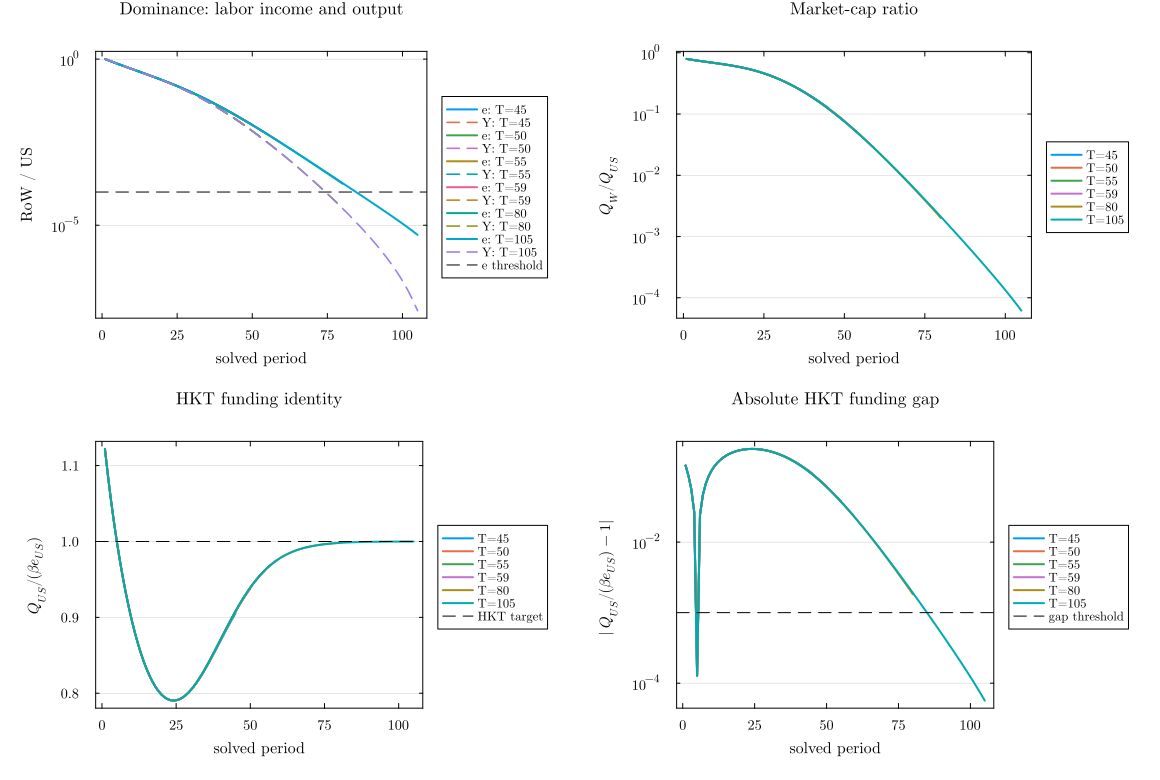

In [8]:
fig_hkt_prereq = plot_hkt_prerequisites(hkt_prereq_plot_cases;
    filename="hkt_scalar_prerequisite_diagnostics.png")
fig_hkt_prereq


## 7. Terminal-Rule Sensitivity At The Selected Full Horizon

The default full run evaluates the local-loglinear reference and conditionally the HKT-scalar rule. The HKT rule is attempted only when the selected residual-safe local-loglinear path passes the entry gate above, and it enters plots and bubble calculations only when the full two-country solution is residual-safe, `Psi` remains regular, and the scalar root is solved to `HKT_SCALAR_ROOT_TOL`. Set `HKT_SCALAR_EXTENDED_TERMINAL_RULES=true` to additionally run the legacy `flat`, `asymptotic_hkt`, and `tail_regression` sensitivity cases; these can be very slow or residual-unsafe at the longest horizon.


In [9]:
terminal_ref = selected_horizon_case
non_hkt_rules = filter(!=(:hkt_scalar_terminal_us), TERMINAL_RULES)
terminal_cases = Any[]
for rule in non_hkt_rules
    if rule == :local_loglinear
        push!(terminal_cases, terminal_ref)
    else
        push!(terminal_cases, run_tail_case(SELECTED_T_REPORT, NO_BUFFER, rule;
                                            branch_iters=terminal_ref.summary.branch_iters,
                                            warm_start_case=terminal_ref))
    end
end

HKT_CASE = nothing
HKT_ADMISSIBLE = false
HKT_ADMISSIBILITY_REASON = HKT_GATE_PASSED ? "not attempted" : selected_hkt_gate_summary.hkt_entry_reason
if HKT_GATE_PASSED
    hkt_outcome = run_residual_safe_case(SELECTED_T_REPORT, NO_BUFFER, :hkt_scalar_terminal_us;
                                         warm_start_case=terminal_ref)
    HKT_CASE = hkt_outcome.case
    scalar_ok = finite_number(HKT_CASE.summary.hkt_scalar_root_residual) &&
                HKT_CASE.summary.hkt_scalar_root_residual <= HKT_SCALAR_ROOT_TOL
    psi_ok = HKT_CASE.status == :ok && HKT_CASE.summary.psi_ok === true
    HKT_ADMISSIBLE = residual_safe(HKT_CASE) && psi_ok && scalar_ok
    reasons = String[]
    residual_safe(HKT_CASE) || push!(reasons, "full two-country HKT-terminal solve is residual-unsafe")
    psi_ok || push!(reasons, "effective-kernel regularity failed")
    scalar_ok || push!(reasons, "HKT scalar terminal root residual exceeds tolerance")
    HKT_ADMISSIBILITY_REASON = isempty(reasons) ? "passed" : join(reasons, " | ")
    push!(terminal_cases, HKT_CASE)
end

terminal_case_summary = [c.summary for c in terminal_cases]
terminal_rows = NamedTuple[]
for c in terminal_cases
    m = comparison_metrics(c, terminal_ref, SELECTED_T_REPORT)
    push!(terminal_rows, merge((;
        T_report=SELECTED_T_REPORT,
        n_buffer=NO_BUFFER,
        terminal_rule=c.summary.terminal_rule,
        reference_rule="local_loglinear",
        T0=SELECTED_T_REPORT,
        status=c.summary.status,
        residual_safe=residual_safe(c),
        max_u_residual=c.summary.max_u_residual,
        max_bgp_residual=c.summary.max_bgp_residual), m))
end

hkt_terminal_decision_rows = [(;
    T_report=SELECTED_T_REPORT,
    hkt_entry_gate=HKT_GATE_PASSED,
    hkt_entry_reason=selected_hkt_gate_summary.hkt_entry_reason,
    hkt_attempted=HKT_CASE !== nothing,
    hkt_residual_safe=HKT_CASE === nothing ? missing : residual_safe(HKT_CASE),
    hkt_scalar_root_residual=HKT_CASE === nothing ? missing : HKT_CASE.summary.hkt_scalar_root_residual,
    psi_ok=HKT_CASE === nothing ? missing : HKT_CASE.summary.psi_ok,
    equity_weights_ok=HKT_CASE === nothing ? missing : HKT_CASE.summary.equity_weights_ok,
    hkt_admissible=HKT_ADMISSIBLE,
    hkt_admissibility_reason=HKT_ADMISSIBILITY_REASON)]
hkt_terminal_decision_cols = ["T_report", "hkt_entry_gate", "hkt_entry_reason", "hkt_attempted",
                              "hkt_residual_safe", "hkt_scalar_root_residual", "psi_ok",
                              "equity_weights_ok", "hkt_admissible", "hkt_admissibility_reason"]

terminal_metric_cols = vcat(["T_report", "n_buffer", "terminal_rule", "reference_rule",
                             "T0", "status", "residual_safe", "max_u_residual", "max_bgp_residual"],
                            metric_column_names())
terminal_path_rows = path_rows_for_cases(terminal_cases;
    experiment="terminal_rule_selected_full_path", T0=SELECTED_T_REPORT)

write_csv(joinpath(OUTDIR, "terminal_rule_case_summary.csv"), terminal_case_summary, summary_cols)
write_csv(joinpath(OUTDIR, "terminal_rule_sensitivity.csv"), terminal_rows, terminal_metric_cols)
write_csv(joinpath(OUTDIR, "terminal_rule_sensitivity_paths.csv"), terminal_path_rows, path_cols)
write_csv(joinpath(OUTDIR, "hkt_scalar_terminal_decision.csv"),
          hkt_terminal_decision_rows, hkt_terminal_decision_cols)

display(markdown_table(terminal_rows,
    ["T_report", "terminal_rule", "status", "residual_safe", "domain_status",
     "max_u_residual", "max_log_q_US_error", "max_log_phi_US_error"];
    maxrows=length(terminal_rows)))
display(markdown_table(hkt_terminal_decision_rows, hkt_terminal_decision_cols;
                       maxrows=length(hkt_terminal_decision_rows)))


Solving T=105, buffer=0, terminal=hkt_scalar_terminal_us, branch_iters=500, warm_T=105


T_report,terminal_rule,status,residual_safe,domain_status,max_u_residual,max_log_q_US_error,max_log_phi_US_error
105,local_loglinear,ok,true,domain_failure,1.034e-06,0.000000,0.000000
105,hkt_scalar_terminal_us,ok,true,domain_failure,1.082e-06,1.493e-07,7.549e-08


T_report,hkt_entry_gate,hkt_entry_reason,hkt_attempted,hkt_residual_safe,hkt_scalar_root_residual,psi_ok,equity_weights_ok,hkt_admissible,hkt_admissibility_reason
105,true,passed,true,true,0.000000,true,false,true,passed


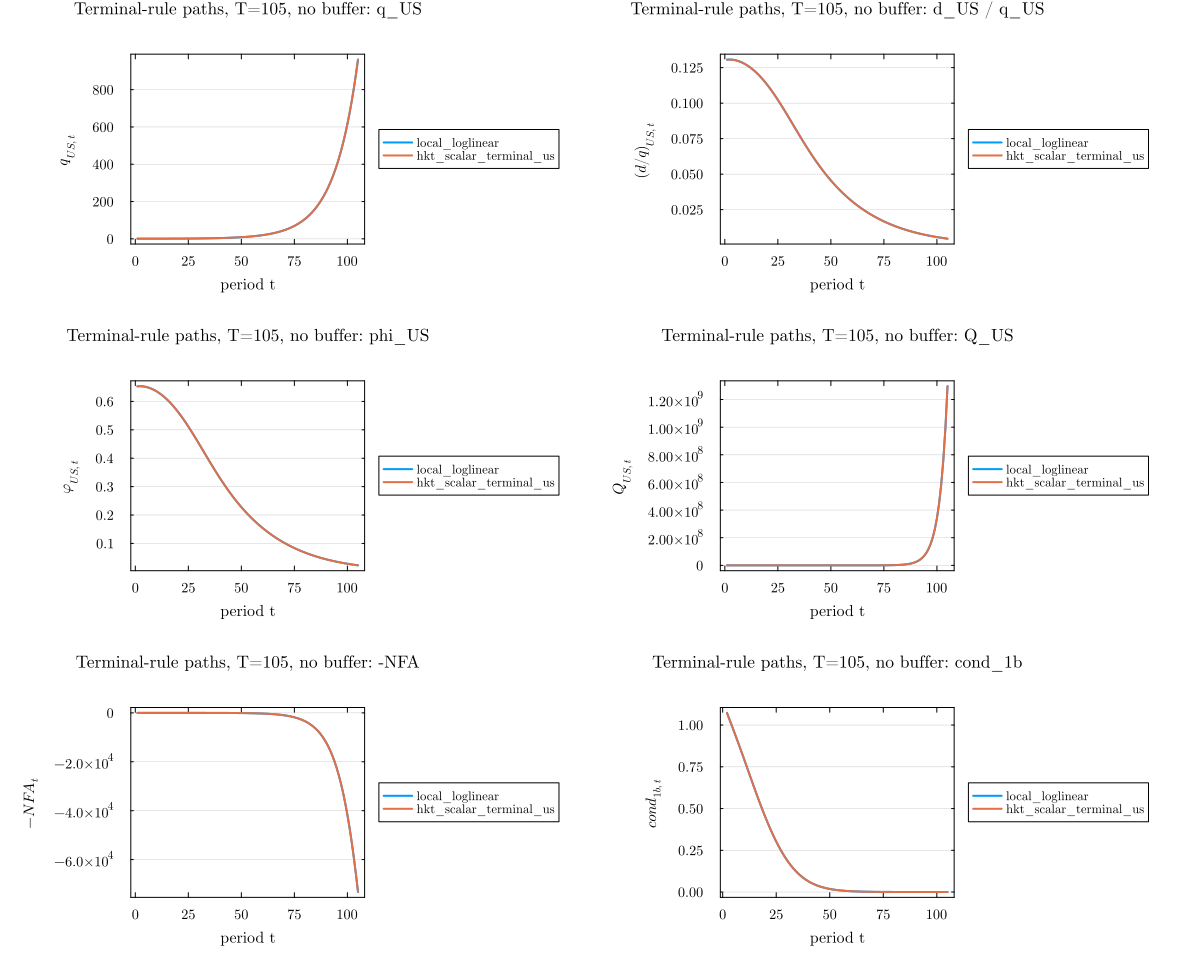

In [10]:
fig_terminal_paths = plot_path_grid(terminal_cases;
    title_prefix="Terminal-rule paths, T=$SELECTED_T_REPORT, no buffer",
    T0=SELECTED_T_REPORT,
    filename="terminal_rule_sensitivity_paths.png",
    label_fn=rule_label)
fig_terminal_paths

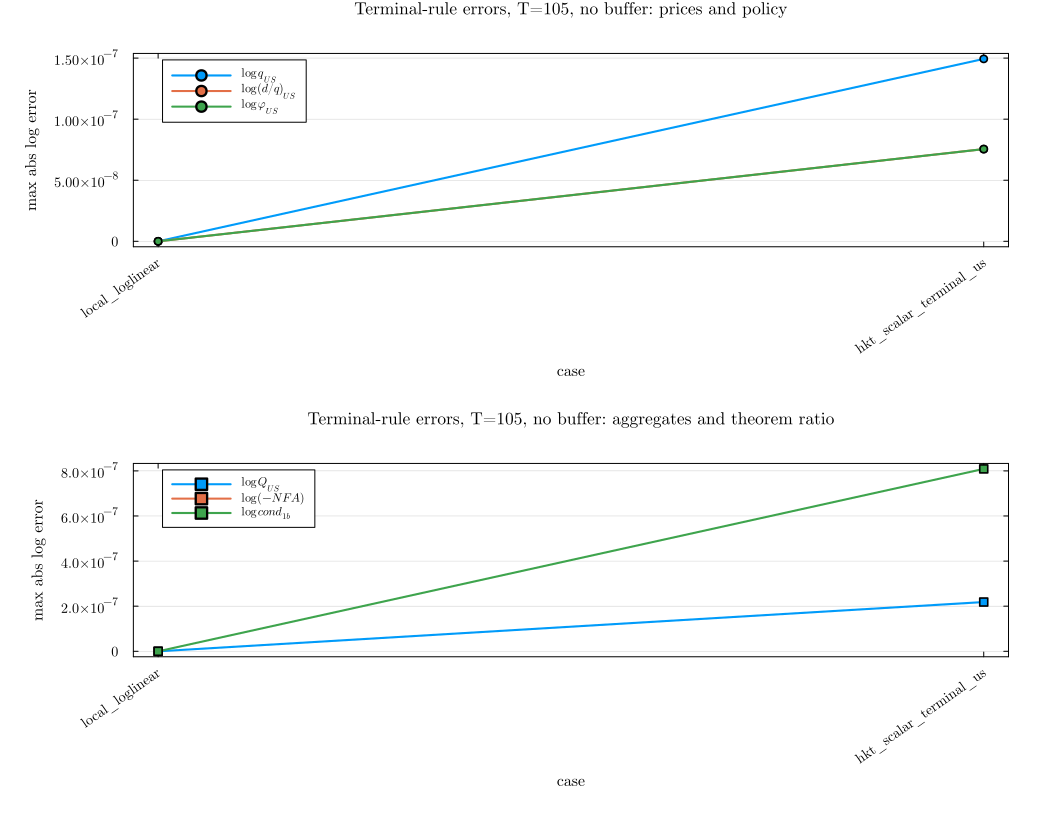

In [11]:
terminal_error_plot_rows = filter(r -> r.status == "ok" && r.residual_safe, terminal_rows)
fig_terminal_errors = plot_error_grid(terminal_error_plot_rows;
    title_prefix="Terminal-rule errors, T=$SELECTED_T_REPORT, no buffer",
    filename="terminal_rule_sensitivity_errors.png",
    label_fn=row_rule_label)
fig_terminal_errors


## 8. Fundamental-Value Horizon Convergence And Bubble Shares

The recursion uses the absorbing-state anchor `v_T = q_US^b(T)`. Therefore the endpoint bubble share is mechanically terminal-contaminated; making `T` larger does not make the new endpoint clean. What improves with horizon is the estimate at a **fixed earlier date**.

For each date `t`, `terminal_anchor_weight` is the exact derivative of `v_t` with respect to the imposed terminal `v_T`:

$$
\frac{\partial v_t}{\partial v_T}
=\prod_{j=t}^{T-1}\left(\pi M^u_j\right).
$$

The convergence table therefore compares fixed-date shares across kernel-regular, residual-safe local-loglinear horizons. This is a horizon-stability diagnostic, not proof of the infinite-horizon value: adding dates also adds dividend/switch terms and slightly changes the equilibrium path. HKT bubble shares are shown only if the independently gated HKT solve is admissible.


In [12]:
fv_admissible(case) = residual_safe(case) && case.summary.psi_ok === true

function terminal_anchor_weights(result)
    u = result.u_path
    T = length(u)
    weights = ones(Float64, T)
    for t in (T - 1):-1:1
        M_u, _ = us_effective_kernel(u[t].R_A_u, u[t].R_A_b,
                                     result.params.γ, result.params.π_persist, u[t].Psi)
        weights[t] = result.params.π_persist * M_u * weights[t + 1]
    end
    return weights
end

function bubble_share_path_rows(cases)
    rows = NamedTuple[]
    for c in cases
        fv_admissible(c) || continue
        result = c.result
        T = length(result.u_path)
        weights = terminal_anchor_weights(result)
        terminal_anchor = result.bgp_seq_extended[T].q_US
        for t in 1:T
            s = result.u_path[t]
            push!(rows, (;
                T_report=c.summary.T_report,
                n_buffer=c.summary.n_buffer,
                terminal_rule=c.summary.terminal_rule,
                t=t,
                periods_to_terminal=T - t,
                terminal_contaminated=t == T,
                terminal_anchor_weight=weights[t],
                terminal_anchor_fraction_of_fundamental_value=weights[t] * terminal_anchor / max(abs(c.fv.v[t]), eps()),
                terminal_anchor_scale_bubble_share_exposure=weights[t] * terminal_anchor / s.q_US,
                bubble_share_derivative_wrt_terminal_value=-weights[t] / s.q_US,
                q_US=s.q_US,
                v_US=c.fv.v[t],
                B_per=c.fv.B_per[t],
                Q_US=s.Q_US,
                V_agg=c.fv.V_agg[t],
                B_agg=c.fv.B_agg[t],
                fundamental_share=c.fv.v[t] / s.q_US,
                bubble_share=c.fv.bubble_share[t],
                NFA=c.nfa.NFA[t],
                NFA_fund=c.nfa.NFA_fund[t],
                NFA_bubble=c.nfa.NFA_bubble[t],
                max_u_residual=c.summary.max_u_residual,
                terminal_successor_phi_US=c.summary.terminal_successor_phi_US))
        end
    end
    return rows
end

function fundamental_horizon_convergence_rows(cases, reference_case; evaluation_dates=FV_EVALUATION_DATES)
    rows = NamedTuple[]
    ref_T = length(reference_case.result.u_path)
    for c in sort(filter(fv_admissible, cases); by=c -> c.summary.T_report)
        T = length(c.result.u_path)
        weights = terminal_anchor_weights(c.result)
        terminal_anchor = c.result.bgp_seq_extended[T].q_US
        for t in evaluation_dates
            t <= T && t <= ref_T || continue
            share = c.fv.bubble_share[t]
            ref_share = reference_case.fv.bubble_share[t]
            push!(rows, (;
                T_report=T,
                reference_T_report=ref_T,
                evaluation_t=t,
                periods_to_terminal=T - t,
                terminal_contaminated=t == T,
                terminal_anchor_weight=weights[t],
                terminal_anchor_fraction_of_fundamental_value=weights[t] * terminal_anchor / max(abs(c.fv.v[t]), eps()),
                terminal_anchor_scale_bubble_share_exposure=weights[t] * terminal_anchor / c.result.u_path[t].q_US,
                bubble_share_derivative_wrt_terminal_value=-weights[t] / c.result.u_path[t].q_US,
                fundamental_share=c.fv.v[t] / c.result.u_path[t].q_US,
                bubble_share=share,
                reference_bubble_share=ref_share,
                bubble_share_difference_from_longest=share - ref_share,
                abs_bubble_share_difference_from_longest=abs(share - ref_share),
                max_u_residual=c.summary.max_u_residual))
        end
    end
    return rows
end

function bubble_share_comparison_rows(ll_case, hkt_case)
    fv_admissible(ll_case) && hkt_case !== nothing && HKT_ADMISSIBLE || return NamedTuple[]
    T = min(length(ll_case.result.u_path), length(hkt_case.result.u_path))
    rows = NamedTuple[]
    for t in 1:T
        push!(rows, (;
            T_report=ll_case.summary.T_report,
            n_buffer=ll_case.summary.n_buffer,
            t=t,
            terminal_contaminated=t == T,
            bubble_share_LL=ll_case.fv.bubble_share[t],
            bubble_share_HKT_scalar=hkt_case.fv.bubble_share[t],
            bubble_share_difference=hkt_case.fv.bubble_share[t] - ll_case.fv.bubble_share[t],
            abs_bubble_share_difference=abs(hkt_case.fv.bubble_share[t] - ll_case.fv.bubble_share[t]),
            fundamental_share_LL=ll_case.fv.v[t] / ll_case.result.u_path[t].q_US,
            fundamental_share_HKT_scalar=hkt_case.fv.v[t] / hkt_case.result.u_path[t].q_US,
            q_US_LL=ll_case.result.u_path[t].q_US,
            q_US_HKT_scalar=hkt_case.result.u_path[t].q_US,
            phi_US_LL=ll_case.result.u_path[t].φ_US,
            phi_US_HKT_scalar=hkt_case.result.u_path[t].φ_US))
    end
    return rows
end

function bubble_share_comparison_summary(rows)
    isempty(rows) && return NamedTuple[]
    j = argmax([r.abs_bubble_share_difference for r in rows])
    r = rows[j]
    return [(;
        T_report=r.T_report,
        n_buffer=r.n_buffer,
        T0=last(rows).t,
        endpoint_is_terminal_contaminated=true,
        t_max_abs_bubble_share_difference=r.t,
        max_abs_bubble_share_difference=r.abs_bubble_share_difference,
        bubble_share_LL_at_t=r.bubble_share_LL,
        bubble_share_HKT_scalar_at_t=r.bubble_share_HKT_scalar,
        endpoint_bubble_share_LL=last(rows).bubble_share_LL,
        endpoint_bubble_share_HKT_scalar=last(rows).bubble_share_HKT_scalar,
        endpoint_fundamental_share_LL=last(rows).fundamental_share_LL,
        endpoint_fundamental_share_HKT_scalar=last(rows).fundamental_share_HKT_scalar)]
end

function plot_bubble_share_paths(cases, comparison_rows; filename::String)
    ok_cases = filter(fv_admissible, cases)
    isempty(ok_cases) && return Markdown.parse("_No residual-safe bubble-share cases to plot._")

    p_bs = plot(title="Bubble share path (endpoint is terminal-contaminated)", xlabel="period t", ylabel=L"B_{Q,t}/Q_{US,t}", legend=:outerright)
    p_fs = plot(title="Fundamental share path", xlabel="period t", ylabel=L"V_{Q,t}/Q_{US,t}", legend=:outerright)
    for c in ok_cases
        T = length(c.result.u_path)
        tt = 1:T
        label = c.summary.terminal_rule
        plot!(p_bs, tt, c.fv.bubble_share[1:T], lw=2.2, label=label)
        plot!(p_fs, tt, [c.fv.v[t] / c.result.u_path[t].q_US for t in 1:T], lw=2.2, label=label)
        scatter!(p_bs, [T], [c.fv.bubble_share[T]], marker=:x, ms=6, label=false)
    end

    if isempty(comparison_rows)
        p_diff = plot(title="HKT comparison omitted: " * HKT_ADMISSIBILITY_REASON,
                      xlabel="period t", ylabel="HKT scalar - LL", legend=false)
    else
        tt = [r.t for r in comparison_rows]
        p_diff = plot(tt, [r.bubble_share_difference for r in comparison_rows], lw=2.2,
                      title="Bubble share difference", xlabel="period t", ylabel="HKT scalar - LL",
                      label="difference")
        hline!(p_diff, [0.0], lc=:black, ls=:dash, lw=1.0, label="zero")
    end

    fig = plot(p_bs, p_fs, p_diff, layout=(3, 1), size=(1040, 920), bottom_margin=8mm)
    savefig(fig, joinpath(OUTDIR, filename))
    return fig
end

fv_safe_horizon_cases = filter(fv_admissible, safe_horizon_cases)
isempty(fv_safe_horizon_cases) && error("No kernel-regular residual-safe horizon is available for fundamental-value analysis")
selected_fv_horizon_case = last(sort(fv_safe_horizon_cases; by=c -> c.summary.T_report))

bubble_share_cases = Any[selected_fv_horizon_case]
HKT_ADMISSIBLE && HKT_CASE.summary.T_report == selected_fv_horizon_case.summary.T_report &&
    push!(bubble_share_cases, HKT_CASE)

bubble_share_rows = bubble_share_path_rows(bubble_share_cases)
bubble_share_comparison = bubble_share_comparison_rows(
    selected_fv_horizon_case,
    HKT_ADMISSIBLE && HKT_CASE.summary.T_report == selected_fv_horizon_case.summary.T_report ? HKT_CASE : nothing)
bubble_share_summary_rows = bubble_share_comparison_summary(bubble_share_comparison)
fundamental_horizon_rows = fundamental_horizon_convergence_rows(
    fv_safe_horizon_cases, selected_fv_horizon_case; evaluation_dates=FV_EVALUATION_DATES)

bubble_share_cols = ["T_report", "n_buffer", "terminal_rule", "t", "periods_to_terminal",
                     "terminal_contaminated", "terminal_anchor_weight",
                     "terminal_anchor_fraction_of_fundamental_value",
                     "terminal_anchor_scale_bubble_share_exposure",
                     "bubble_share_derivative_wrt_terminal_value", "q_US", "v_US", "B_per",
                     "Q_US", "V_agg", "B_agg", "fundamental_share", "bubble_share",
                     "NFA", "NFA_fund", "NFA_bubble", "max_u_residual",
                     "terminal_successor_phi_US"]

bubble_share_comparison_cols = ["T_report", "n_buffer", "t", "terminal_contaminated",
                                "bubble_share_LL", "bubble_share_HKT_scalar",
                                "bubble_share_difference", "abs_bubble_share_difference",
                                "fundamental_share_LL", "fundamental_share_HKT_scalar",
                                "q_US_LL", "q_US_HKT_scalar", "phi_US_LL", "phi_US_HKT_scalar"]

bubble_share_summary_cols = ["T_report", "n_buffer", "T0", "endpoint_is_terminal_contaminated",
                             "t_max_abs_bubble_share_difference", "max_abs_bubble_share_difference",
                             "bubble_share_LL_at_t", "bubble_share_HKT_scalar_at_t",
                             "endpoint_bubble_share_LL", "endpoint_bubble_share_HKT_scalar",
                             "endpoint_fundamental_share_LL", "endpoint_fundamental_share_HKT_scalar"]

fundamental_horizon_cols = ["T_report", "reference_T_report", "evaluation_t",
                            "periods_to_terminal", "terminal_contaminated",
                            "terminal_anchor_weight", "terminal_anchor_fraction_of_fundamental_value",
                            "terminal_anchor_scale_bubble_share_exposure",
                            "bubble_share_derivative_wrt_terminal_value", "fundamental_share", "bubble_share", "reference_bubble_share",
                            "bubble_share_difference_from_longest",
                            "abs_bubble_share_difference_from_longest", "max_u_residual"]

write_csv(joinpath(OUTDIR, "bubble_share_paths.csv"), bubble_share_rows, bubble_share_cols)
write_csv(joinpath(OUTDIR, "bubble_share_terminal_rule_comparison.csv"), bubble_share_comparison, bubble_share_comparison_cols)
write_csv(joinpath(OUTDIR, "bubble_share_terminal_rule_summary.csv"), bubble_share_summary_rows, bubble_share_summary_cols)
write_csv(joinpath(OUTDIR, "fundamental_value_horizon_convergence.csv"),
          fundamental_horizon_rows, fundamental_horizon_cols)

display(markdown_table(fundamental_horizon_rows,
    ["T_report", "evaluation_t", "periods_to_terminal", "terminal_anchor_weight",
     "terminal_anchor_scale_bubble_share_exposure", "bubble_share",
     "bubble_share_difference_from_longest", "terminal_contaminated"];
    maxrows=length(fundamental_horizon_rows)))
display(markdown_table(bubble_share_summary_rows,
    ["T_report", "T0", "endpoint_is_terminal_contaminated",
     "max_abs_bubble_share_difference", "endpoint_bubble_share_LL",
     "endpoint_bubble_share_HKT_scalar"];
    maxrows=length(bubble_share_summary_rows)))


T_report,evaluation_t,periods_to_terminal,terminal_anchor_weight,terminal_anchor_scale_bubble_share_exposure,bubble_share,bubble_share_difference_from_longest,terminal_contaminated
45,1,44,4.343e-05,3.756e-06,0.000293,0.000210,false
45,20,25,0.011542,0.000666,0.051881,0.037162,false
45,40,5,0.489902,0.009006,0.701835,0.502937,false
46,1,45,3.792e-05,3.021e-06,0.000277,0.000193,false
46,20,26,0.010076,0.000535,0.049015,0.034296,false
46,40,6,0.427770,0.007242,0.662943,0.464045,false
47,1,46,3.317e-05,2.432e-06,0.000262,0.000179,false
47,20,27,0.008816,0.000431,0.046420,0.031701,false
47,40,7,0.374321,0.005829,0.627744,0.428845,false
48,1,47,2.908e-05,1.960e-06,0.000249,0.000166,false


T_report,T0,endpoint_is_terminal_contaminated,max_abs_bubble_share_difference,endpoint_bubble_share_LL,endpoint_bubble_share_HKT_scalar
105,105,true,2.522e-08,1.000000,1.000000


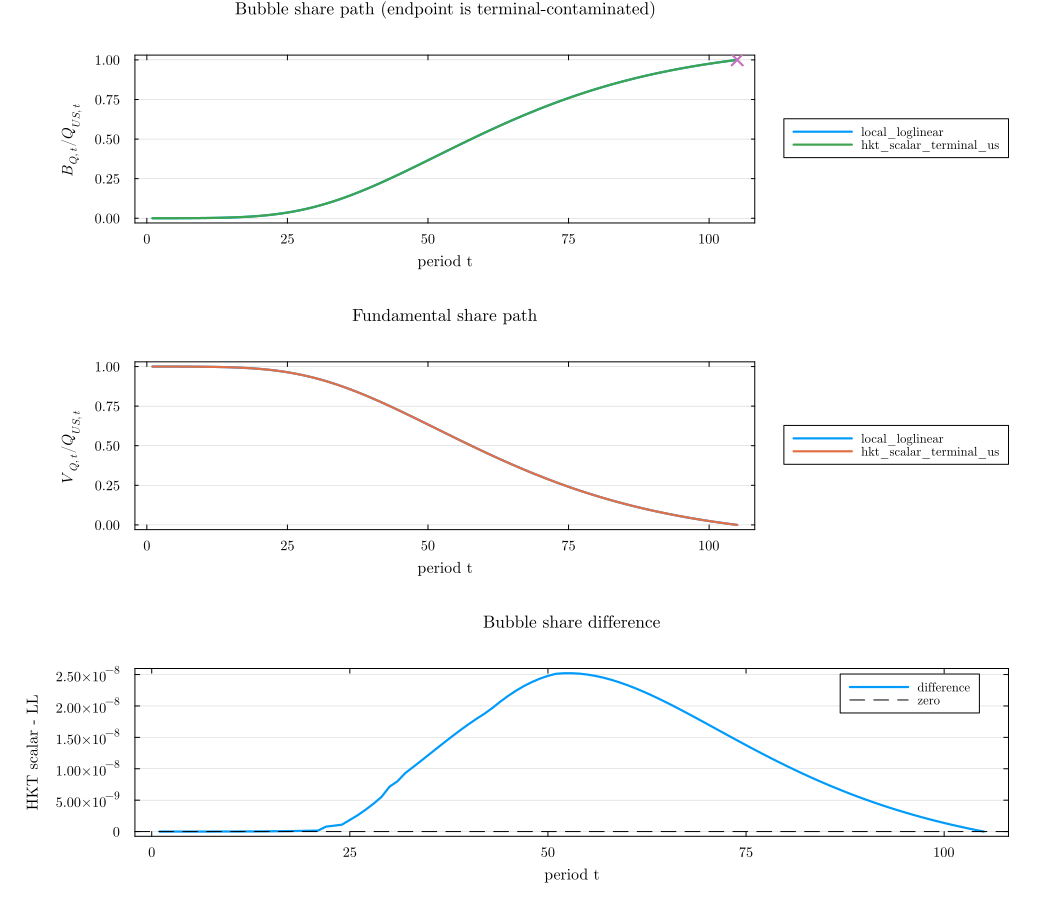

In [13]:
fig_bubble_share = plot_bubble_share_paths(bubble_share_cases, bubble_share_comparison;
    filename="bubble_share_paths.png")
fig_bubble_share

## 9. Output Files

Main files:

- `residual_safe_horizon_progress.csv` (rewritten after every candidate)
- `residual_safe_horizon_attempts.csv` (includes iteration-budget retries)
- `residual_safe_horizon_search.csv`
- `selected_horizon_summary.csv`
- `selected_horizon_cold_verification.csv`
- `hkt_scalar_prerequisite_summary.csv`
- `hkt_scalar_prerequisite_tail_rows.csv`
- `hkt_scalar_prerequisite_diagnostics.png`
- `hkt_scalar_terminal_decision.csv`
- `terminal_rule_case_summary.csv`
- `terminal_rule_sensitivity.csv`
- `terminal_rule_sensitivity_paths.csv`
- `terminal_rule_sensitivity_paths.png`
- `terminal_rule_sensitivity_errors.png`
- `fundamental_value_horizon_convergence.csv`
- `bubble_share_paths.csv`
- `bubble_share_terminal_rule_comparison.csv`
- `bubble_share_terminal_rule_summary.csv`
- `bubble_share_paths.png`


In [14]:
println("Saved output files in:")
println("  ", OUTDIR)
for f in sort(readdir(OUTDIR))
    println("  ", joinpath(OUTDIR, f))
end

Saved output files in:
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down/bubble_share_paths.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down/bubble_share_paths.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down/bubble_share_terminal_rule_comparison.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down/bubble_share_terminal_rule_summary.csv
  /Users/jipengcheng/Library/Mobile Documents/com~